In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/urban-flood-modelling/test_2d_edges_dynamic_all.csv
/kaggle/input/competitions/urban-flood-modelling/test_2d_edges_static.csv
/kaggle/input/competitions/urban-flood-modelling/timesteps.csv
/kaggle/input/competitions/urban-flood-modelling/sample_submission.csv
/kaggle/input/competitions/urban-flood-modelling/test_2d_nodes_dynamic_all.csv
/kaggle/input/competitions/urban-flood-modelling/test_1d_edges_dynamic_all.csv
/kaggle/input/competitions/urban-flood-modelling/1d2d_connections.csv
/kaggle/input/competitions/urban-flood-modelling/1d_nodes_static.csv
/kaggle/input/competitions/urban-flood-modelling/2d_nodes_dynamic_all.csv
/kaggle/input/competitions/urban-flood-modelling/2d_edges_dynamic_all.csv
/kaggle/input/competitions/urban-flood-modelling/test_timesteps.csv
/kaggle/input/competitions/urban-flood-modelling/1d_edge_index.csv
/kaggle/input/competitions/urban-flood-modelling/2d_edges_static.csv
/kaggle/input/competitions/urban-flood-modelling/test_2d_edge_in

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [3]:
BASE_PATH = Path('/kaggle/input')
for root, dirs, files in os.walk(BASE_PATH):
    level = root.replace(str(BASE_PATH), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in sorted(files):
        fpath = os.path.join(root, file)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'{subindent}{file} ({size_mb:.2f} MB)')

input/
  competitions/
    urban-flood-modelling/
      1d2d_connections.csv (0.00 MB)
      1d_edge_index.csv (0.00 MB)
      1d_edges_dynamic_all.csv (0.03 MB)
      1d_edges_static.csv (0.00 MB)
      1d_nodes_dynamic_all.csv (0.03 MB)
      1d_nodes_static.csv (0.00 MB)
      2d_edge_index.csv (0.11 MB)
      2d_edges_dynamic_all.csv (21.51 MB)
      2d_edges_static.csv (0.28 MB)
      2d_nodes_dynamic_all.csv (17.45 MB)
      2d_nodes_static.csv (0.29 MB)
      sample_submission.csv (1037.02 MB)
      sample_submission.parquet (208.87 MB)
      test_1d2d_connections.csv (0.00 MB)
      test_1d_edge_index.csv (0.00 MB)
      test_1d_edges_dynamic_all.csv (0.06 MB)
      test_1d_edges_static.csv (0.00 MB)
      test_1d_nodes_dynamic_all.csv (0.06 MB)
      test_1d_nodes_static.csv (0.00 MB)
      test_2d_edge_index.csv (0.11 MB)
      test_2d_edges_dynamic_all.csv (36.19 MB)
      test_2d_edges_static.csv (0.28 MB)
      test_2d_nodes_dynamic_all.csv (38.73 MB)
      test_2d_nodes_s

In [4]:
# %% CELL 3 — Helper Functions
def load_csv_safe(path, **kwargs):
    """Load CSV with automatic detection of common issues."""
    try:
        df = pd.read_csv(path, **kwargs)
        return df
    except Exception as e:
        print(f"  ⚠️ Error loading {path}: {e}")
        return None

def describe_df(df, name="DataFrame"):
    """Print comprehensive description of a DataFrame."""
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Dtypes:\n{df.dtypes.to_string()}")
    print(f"\n  First 3 rows:")
    print(df.head(3).to_string())
    print(f"\n  Basic Stats:")
    print(df.describe().to_string())
    print(f"\n  Null counts:\n{df.isnull().sum().to_string()}")
    return df

In [5]:
# %% CELL 4 — Load ALL Files (adapt paths to your data)
# We'll try to load files for Model 1 and Model 2

data = {}  # Will hold all loaded DataFrames

# File prefixes for train vs test
file_configs = {
    'train': {
        '1d_nodes_static': '1d_nodes_static.csv',
        '2d_nodes_static': '2d_nodes_static.csv',  # might be 2d_nodes_index.csv
        '1d_edges_static': '1d_edges_static.csv',
        '2d_edges_static': '2d_edges_static.csv',  # might be 2d_edges_index.csv
        '1d_edge_index': '1d_edge_index.csv',
        '2d_edge_index': '2d_edge_index.csv',
        '1d2d_connections': '1d2d_connections.csv',
    },
    'test': {
        '1d_nodes_static': 'test_1d_nodes_static.csv',
        '2d_nodes_static': 'test_2d_nodes_static.csv',
        '1d_edges_static': 'test_1d_edges_static.csv',
        '2d_edges_static': 'test_2d_edges_static.csv',
        '1d_edge_index': 'test_1d_edge_index.csv',
        '2d_edge_index': 'test_2d_edge_index.csv',
        '1d2d_connections': 'test_1d2d_connections.csv',
    }
}

dynamic_files = [
    '1d_nodes_dynamic_all.csv',
    '2d_nodes_dynamic_all.csv',
    '1d_edges_dynamic_all.csv',
    '2d_edges_dynamic_all.csv',
    'timesteps.csv',
]

# Scan the directory and load everything we find
print("\n📦 LOADING ALL AVAILABLE DATA")
print("-" * 60)

all_files = []
for root, dirs, files in os.walk(BASE_PATH):
    for f in files:
        if f.endswith('.csv') or f.endswith('.parquet'):
            full_path = os.path.join(root, f)
            rel_path = os.path.relpath(full_path, BASE_PATH)
            all_files.append((rel_path, full_path))
            
print(f"Found {len(all_files)} data files:")
for rel, full in sorted(all_files):
    print(f"  • {rel}")



📦 LOADING ALL AVAILABLE DATA
------------------------------------------------------------
Found 26 data files:
  • competitions/urban-flood-modelling/1d2d_connections.csv
  • competitions/urban-flood-modelling/1d_edge_index.csv
  • competitions/urban-flood-modelling/1d_edges_dynamic_all.csv
  • competitions/urban-flood-modelling/1d_edges_static.csv
  • competitions/urban-flood-modelling/1d_nodes_dynamic_all.csv
  • competitions/urban-flood-modelling/1d_nodes_static.csv
  • competitions/urban-flood-modelling/2d_edge_index.csv
  • competitions/urban-flood-modelling/2d_edges_dynamic_all.csv
  • competitions/urban-flood-modelling/2d_edges_static.csv
  • competitions/urban-flood-modelling/2d_nodes_dynamic_all.csv
  • competitions/urban-flood-modelling/2d_nodes_static.csv
  • competitions/urban-flood-modelling/sample_submission.csv
  • competitions/urban-flood-modelling/sample_submission.parquet
  • competitions/urban-flood-modelling/test_1d2d_connections.csv
  • competitions/urban-flood-mo

In [6]:
# %% CELL 5 — Load and Explore Each File
print("\n" + "=" * 60)
print("📊 DETAILED FILE EXPLORATION")
print("=" * 60)

loaded = {}
for rel_path, full_path in sorted(all_files):
    if full_path.endswith('.csv'):
        df = load_csv_safe(full_path)
        if df is not None:
            loaded[rel_path] = df
            describe_df(df, name=rel_path)
    elif full_path.endswith('.parquet'):
        try:
            df = pd.read_parquet(full_path)
            loaded[rel_path] = df
            describe_df(df, name=rel_path)
        except Exception as e:
            print(f"  ⚠️ Error loading {rel_path}: {e}")


📊 DETAILED FILE EXPLORATION

  competitions/urban-flood-modelling/1d2d_connections.csv
  Shape: (16, 3)
  Columns: ['connection_idx', 'node_1d', 'node_2d']
  Dtypes:
connection_idx    int64
node_1d           int64
node_2d           int64

  First 3 rows:
   connection_idx  node_1d  node_2d
0               0        0      503
1               1       13     3669
2               2       12     3588

  Basic Stats:
       connection_idx    node_1d      node_2d
count       16.000000  16.000000    16.000000
mean         7.500000   7.500000  2465.687500
std          4.760952   4.760952  1122.236263
min          0.000000   0.000000   503.000000
25%          3.750000   3.750000  1989.750000
50%          7.500000   7.500000  2945.500000
75%         11.250000  11.250000  3327.750000
max         15.000000  15.000000  3669.000000

  Null counts:
connection_idx    0
node_1d           0
node_2d           0

  competitions/urban-flood-modelling/1d_edge_index.csv
  Shape: (16, 3)
  Columns: ['edge_idx

In [7]:
# %% CELL 6 — Identify Train/Test Dynamic Data  
print("\n" + "=" * 60)
print("🔍 IDENTIFYING DYNAMIC DATA FILES")
print("=" * 60)

train_dynamic = {k: v for k, v in loaded.items() if 'dynamic' in k and 'test' not in k.lower()}
test_dynamic = {k: v for k, v in loaded.items() if 'dynamic' in k and 'test' in k.lower()}

print(f"\nTrain dynamic files ({len(train_dynamic)}):")
for k, v in train_dynamic.items():
    print(f"  • {k}: shape={v.shape}")

print(f"\nTest dynamic files ({len(test_dynamic)}):")
for k, v in test_dynamic.items():
    print(f"  • {k}: shape={v.shape}")



🔍 IDENTIFYING DYNAMIC DATA FILES

Train dynamic files (4):
  • competitions/urban-flood-modelling/1d_edges_dynamic_all.csv: shape=(1504, 4)
  • competitions/urban-flood-modelling/1d_nodes_dynamic_all.csv: shape=(1598, 4)
  • competitions/urban-flood-modelling/2d_edges_dynamic_all.csv: shape=(745890, 4)
  • competitions/urban-flood-modelling/2d_nodes_dynamic_all.csv: shape=(349304, 5)

Test dynamic files (4):
  • competitions/urban-flood-modelling/test_1d_edges_dynamic_all.csv: shape=(7120, 4)
  • competitions/urban-flood-modelling/test_1d_nodes_dynamic_all.csv: shape=(7565, 4)
  • competitions/urban-flood-modelling/test_2d_edges_dynamic_all.csv: shape=(3531075, 4)
  • competitions/urban-flood-modelling/test_2d_nodes_dynamic_all.csv: shape=(1653620, 5)


In [8]:
# %% CELL 7 — Graph Structure Analysis
print("\n" + "=" * 60)
print("🕸️ GRAPH STRUCTURE ANALYSIS")
print("=" * 60)

# Find edge index and connection files
edge_files = {k: v for k, v in loaded.items() if 'edge_index' in k or 'connections' in k}

for name, df in edge_files.items():
    print(f"\n--- {name} ---")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    print(df.head(5).to_string())
    
    # If it looks like an edge index, analyze connectivity
    if df.shape[1] >= 2:
        col1, col2 = df.columns[0], df.columns[1]
        unique_src = df[col1].nunique()
        unique_dst = df[col2].nunique()
        print(f"  Unique source nodes: {unique_src}")
        print(f"  Unique dest nodes: {unique_dst}")
        print(f"  Total edges: {len(df)}")

# Count nodes
static_node_files = {k: v for k, v in loaded.items() if 'nodes_static' in k or 'nodes_index' in k}
for name, df in static_node_files.items():
    print(f"\n📍 {name}: {len(df)} nodes, features: {list(df.columns)}")



🕸️ GRAPH STRUCTURE ANALYSIS

--- competitions/urban-flood-modelling/1d2d_connections.csv ---
  Shape: (16, 3)
  Columns: ['connection_idx', 'node_1d', 'node_2d']
   connection_idx  node_1d  node_2d
0               0        0      503
1               1       13     3669
2               2       12     3588
3               3        3     3595
4               4        4     3600
  Unique source nodes: 16
  Unique dest nodes: 16
  Total edges: 16

--- competitions/urban-flood-modelling/1d_edge_index.csv ---
  Shape: (16, 3)
  Columns: ['edge_idx', 'from_node', 'to_node']
   edge_idx  from_node  to_node
0         0          0       16
1         1         13       12
2         2          3       13
3         3          4        3
4         4         14        4
  Unique source nodes: 16
  Unique dest nodes: 16
  Total edges: 16

--- competitions/urban-flood-modelling/2d_edge_index.csv ---
  Shape: (7935, 3)
  Columns: ['edge_idx', 'from_node', 'to_node']
   edge_idx  from_node  to_node
0    


💧 WATER LEVEL ANALYSIS


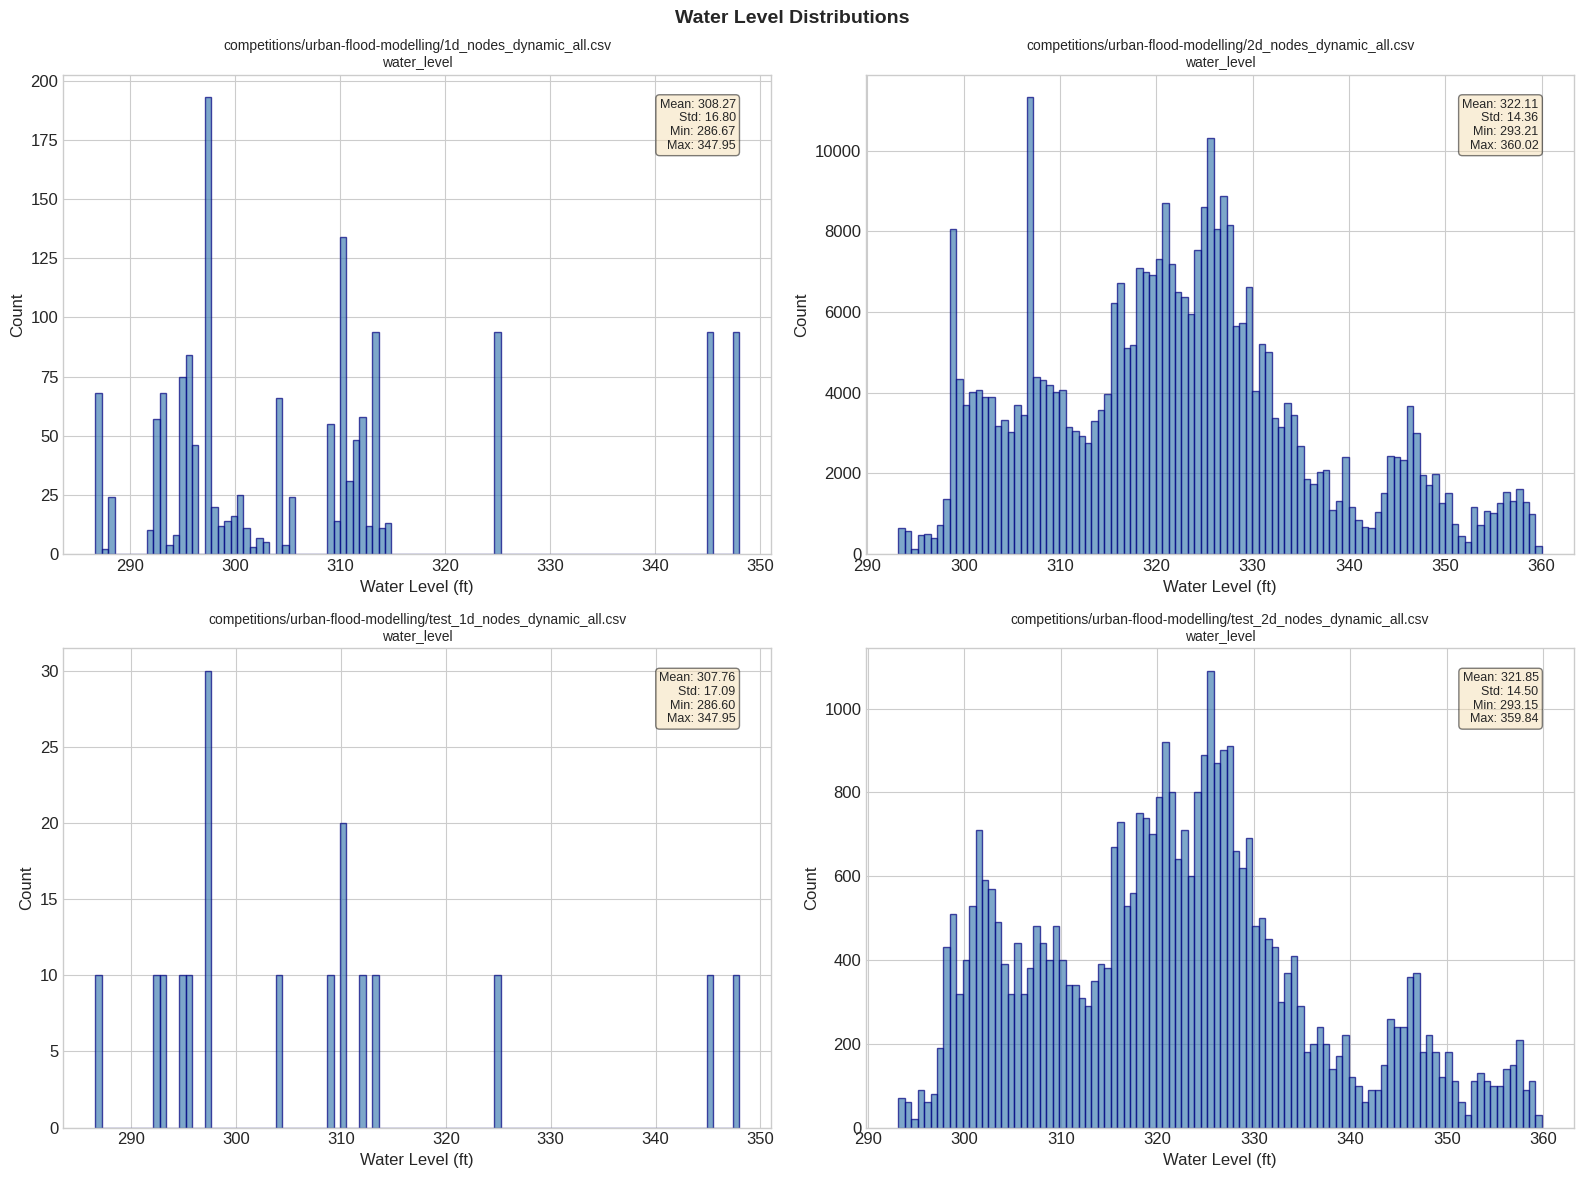

✅ Saved: water_level_distributions.png


In [9]:
# %% CELL 8 — Water Level Distribution Analysis
print("\n" + "=" * 60)
print("💧 WATER LEVEL ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_idx = 0
for name, df in loaded.items():
    if 'nodes_dynamic' not in name:
        continue
    
    # Find the water level column
    wl_cols = [c for c in df.columns if 'water' in c.lower() and 'level' in c.lower()]
    if not wl_cols:
        wl_cols = [c for c in df.columns if 'water_level' in c.lower()]
    
    if wl_cols and plot_idx < 4:
        wl_col = wl_cols[0]
        ax = axes[plot_idx // 2, plot_idx % 2]
        
        wl_data = df[wl_col].dropna()
        ax.hist(wl_data, bins=100, alpha=0.7, color='steelblue', edgecolor='navy')
        ax.set_title(f'{name}\n{wl_col}', fontsize=10)
        ax.set_xlabel('Water Level (ft)')
        ax.set_ylabel('Count')
        
        # Add statistics as text
        stats_text = f'Mean: {wl_data.mean():.2f}\nStd: {wl_data.std():.2f}\nMin: {wl_data.min():.2f}\nMax: {wl_data.max():.2f}'
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plot_idx += 1

plt.suptitle('Water Level Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('water_level_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: water_level_distributions.png")



⏱️ TEMPORAL DYNAMICS
Found 4 dynamic node files: ['competitions/urban-flood-modelling/1d_nodes_dynamic_all.csv', 'competitions/urban-flood-modelling/2d_nodes_dynamic_all.csv', 'competitions/urban-flood-modelling/test_1d_nodes_dynamic_all.csv', 'competitions/urban-flood-modelling/test_2d_nodes_dynamic_all.csv']

competitions/urban-flood-modelling/1d_nodes_dynamic_all.csv: ts_col=timestep, wl_cols=['water_level'], node_cols=['node_idx']

competitions/urban-flood-modelling/2d_nodes_dynamic_all.csv: ts_col=timestep, wl_cols=['water_level'], node_cols=['node_idx']

competitions/urban-flood-modelling/test_1d_nodes_dynamic_all.csv: ts_col=timestep, wl_cols=['water_level'], node_cols=['node_idx']

competitions/urban-flood-modelling/test_2d_nodes_dynamic_all.csv: ts_col=timestep, wl_cols=['water_level'], node_cols=['node_idx']


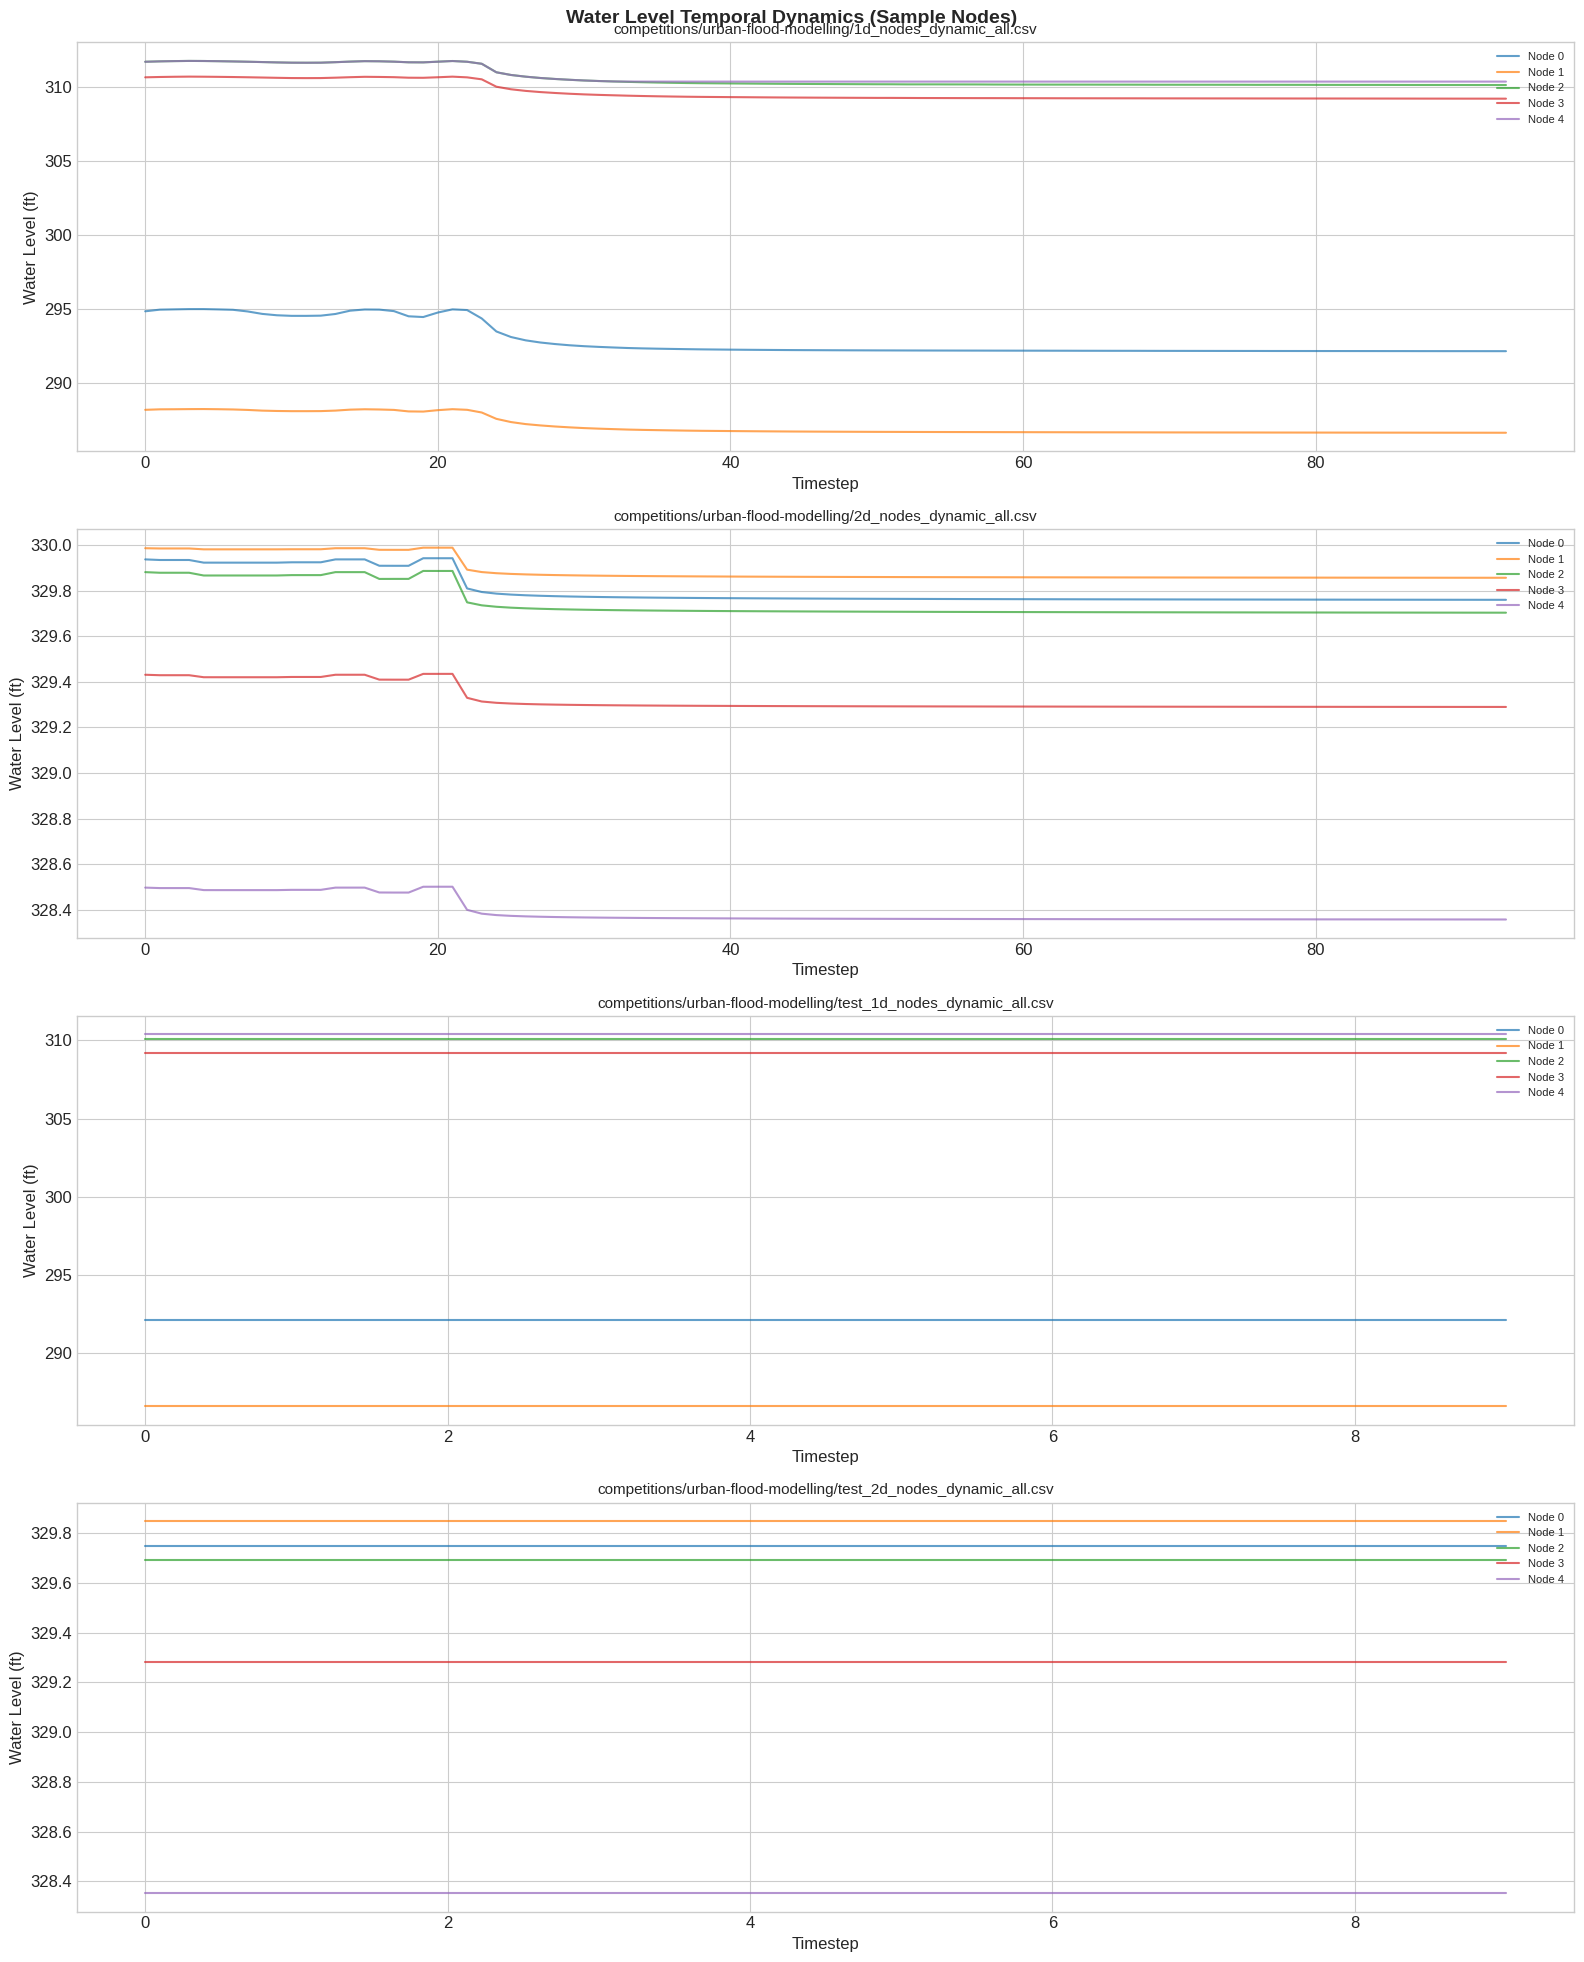

✅ Saved: temporal_dynamics.png


In [10]:
# %% CELL 9 — Temporal Dynamics: Water Level Over Time
print("\n" + "=" * 60)
print("⏱️ TEMPORAL DYNAMICS")
print("=" * 60)

# Filter FIRST, then iterate — don't use enumerate on the full loaded dict
dynamic_node_files = [(name, df) for name, df in loaded.items() if 'nodes_dynamic' in name]
print(f"Found {len(dynamic_node_files)} dynamic node files: {[n for n,_ in dynamic_node_files]}")

fig, axes = plt.subplots(max(len(dynamic_node_files), 1), 1, figsize=(16, 5 * max(len(dynamic_node_files), 1)))
if len(dynamic_node_files) == 1:
    axes = [axes]  # ensure iterable

for idx, (name, df) in enumerate(dynamic_node_files[:4]):  # cap at 4 subplots
    ts_col  = next((c for c in df.columns if 'timestep' in c.lower() or 'time' in c.lower()), None)
    wl_cols = [c for c in df.columns if 'water' in c.lower() and 'level' in c.lower()]
    node_cols = [c for c in df.columns if 'node' in c.lower() and 'id' in c.lower()]

    print(f"\n{name}: ts_col={ts_col}, wl_cols={wl_cols}, node_cols={node_cols}")

    if not ts_col or not wl_cols:
        print(f"  ⚠️ Skipping — missing timestep or water_level column. Columns: {list(df.columns)}")
        continue

    wl = wl_cols[0]
    ax = axes[idx]

    if node_cols:
        node_col = node_cols[0]
        sample_nodes = df[node_col].unique()[:5]
        for node_id in sample_nodes:
            node_data = df[df[node_col] == node_id].sort_values(ts_col)
            ax.plot(node_data[ts_col], node_data[wl], alpha=0.7, label=f'Node {node_id}')
        ax.legend(fontsize=8, loc='upper right')
    else:
        timeseries = df.groupby(ts_col)[wl].mean()
        ax.plot(timeseries.index, timeseries.values, color='steelblue', linewidth=1.5)

    ax.set_title(f'{name}', fontsize=11)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Water Level (ft)')

plt.suptitle('Water Level Temporal Dynamics (Sample Nodes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('temporal_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: temporal_dynamics.png")


🌧️ RAINFALL ANALYSIS


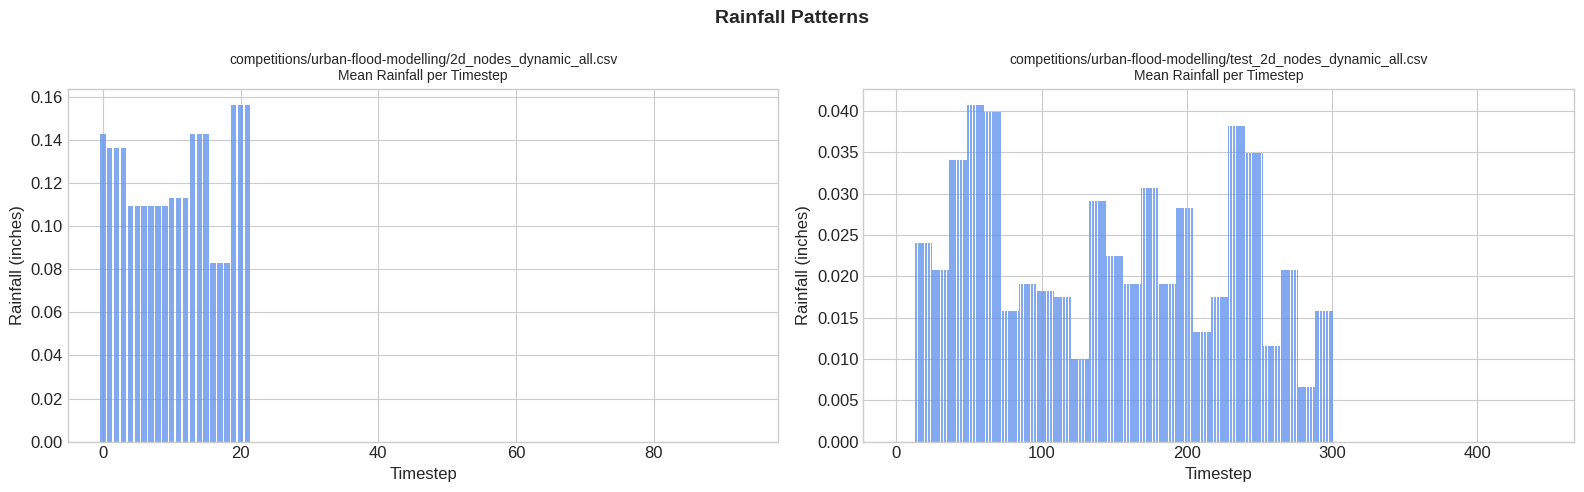

✅ Saved: rainfall_patterns.png


In [11]:
# %% CELL 10 — Rainfall Analysis
print("\n" + "=" * 60)
print("🌧️ RAINFALL ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_idx = 0
for name, df in loaded.items():
    if '2d_nodes_dynamic' not in name:
        continue
    
    # Find rainfall column
    rain_cols = [c for c in df.columns if 'rain' in c.lower()]
    ts_col = [c for c in df.columns if 'timestep' in c.lower() or 'time' in c.lower()]
    
    if rain_cols and ts_col and plot_idx < 2:
        rain_col = rain_cols[0]
        ts = ts_col[0]
        
        # Average rainfall per timestep
        avg_rain = df.groupby(ts)[rain_col].mean()
        
        ax = axes[plot_idx]
        ax.bar(avg_rain.index, avg_rain.values, color='cornflowerblue', alpha=0.8)
        ax.set_title(f'{name}\nMean Rainfall per Timestep', fontsize=10)
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Rainfall (inches)')
        
        plot_idx += 1

plt.suptitle('Rainfall Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rainfall_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rainfall_patterns.png")



📈 FEATURE CORRELATIONS


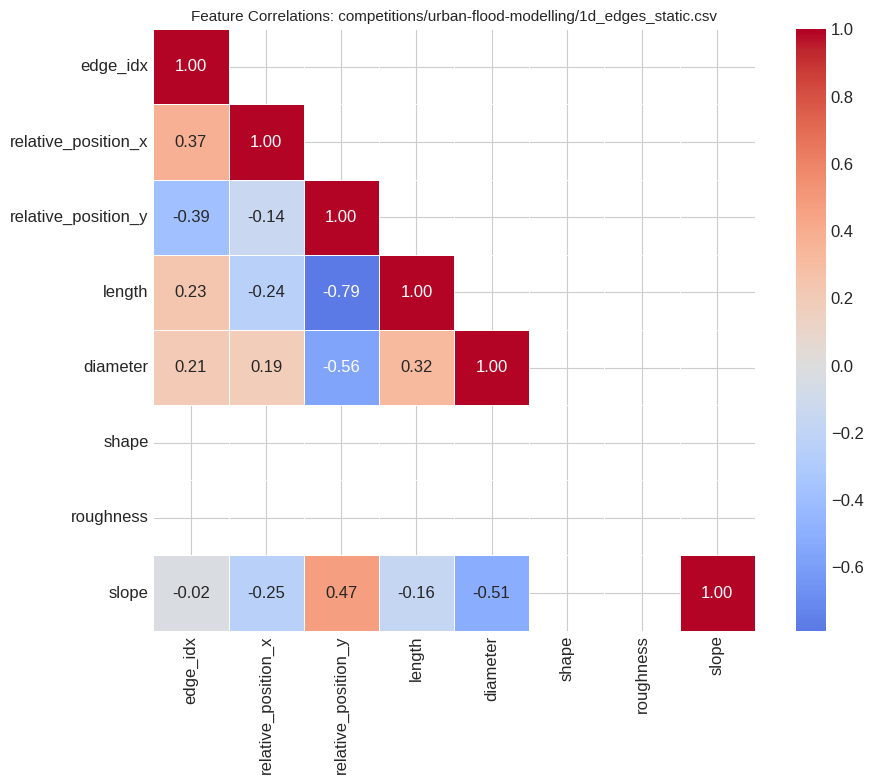

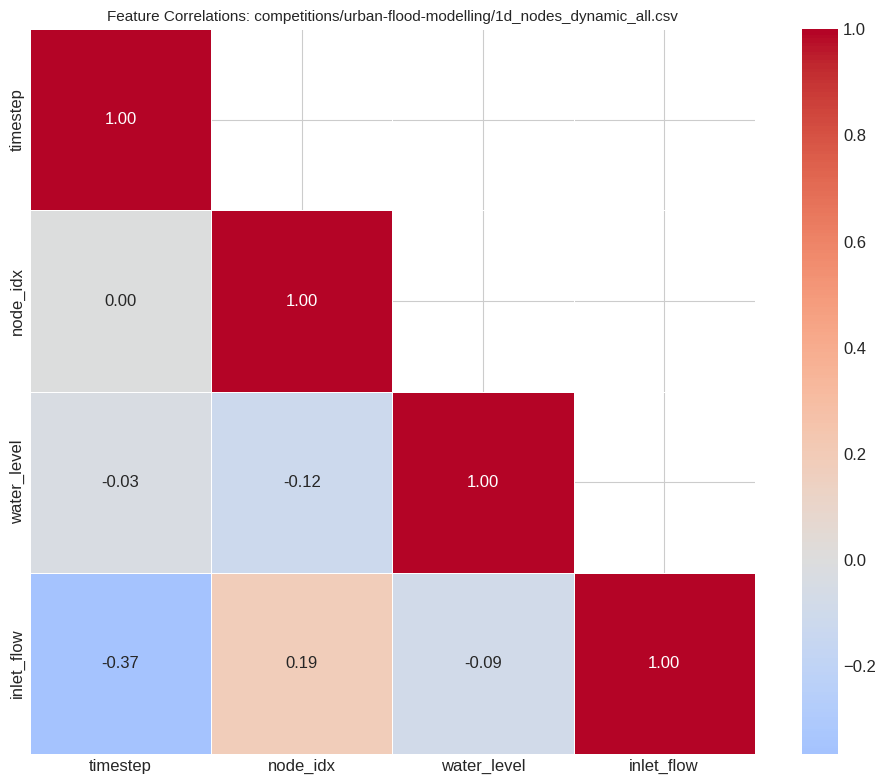

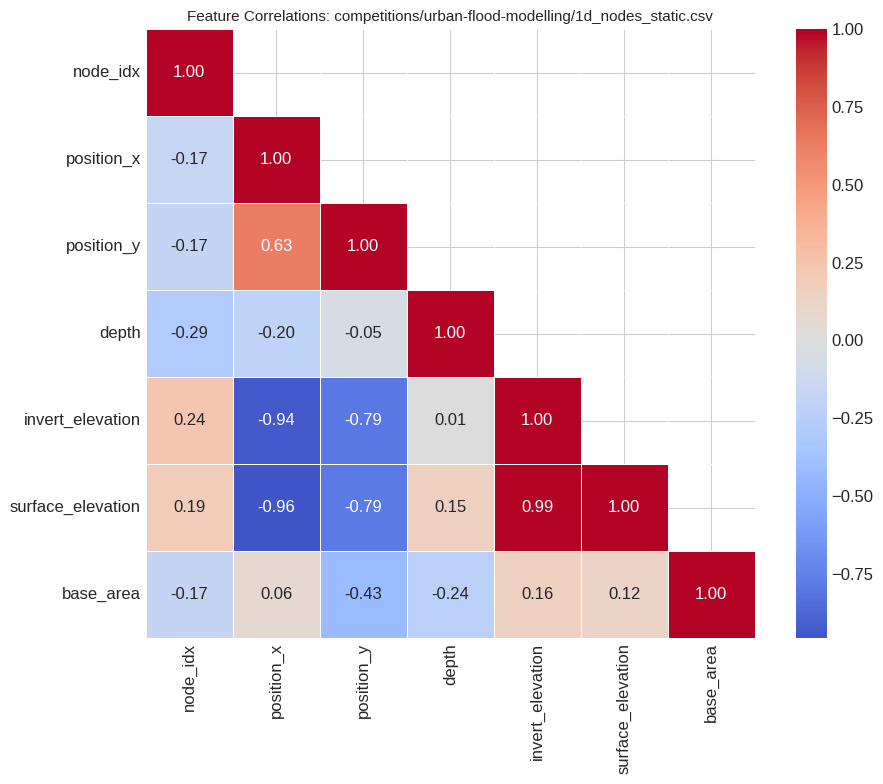

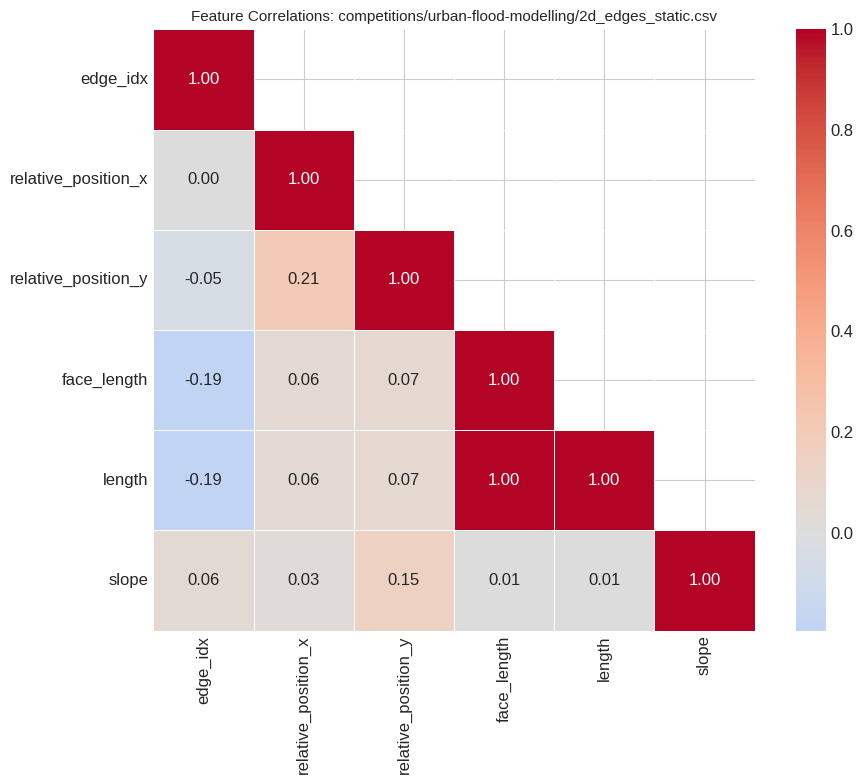

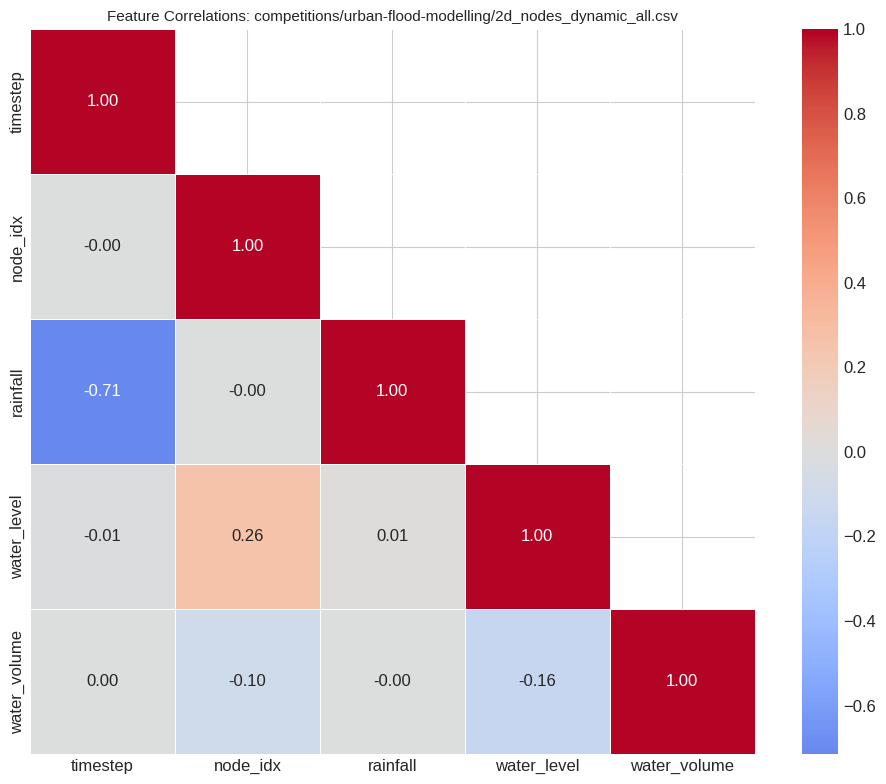

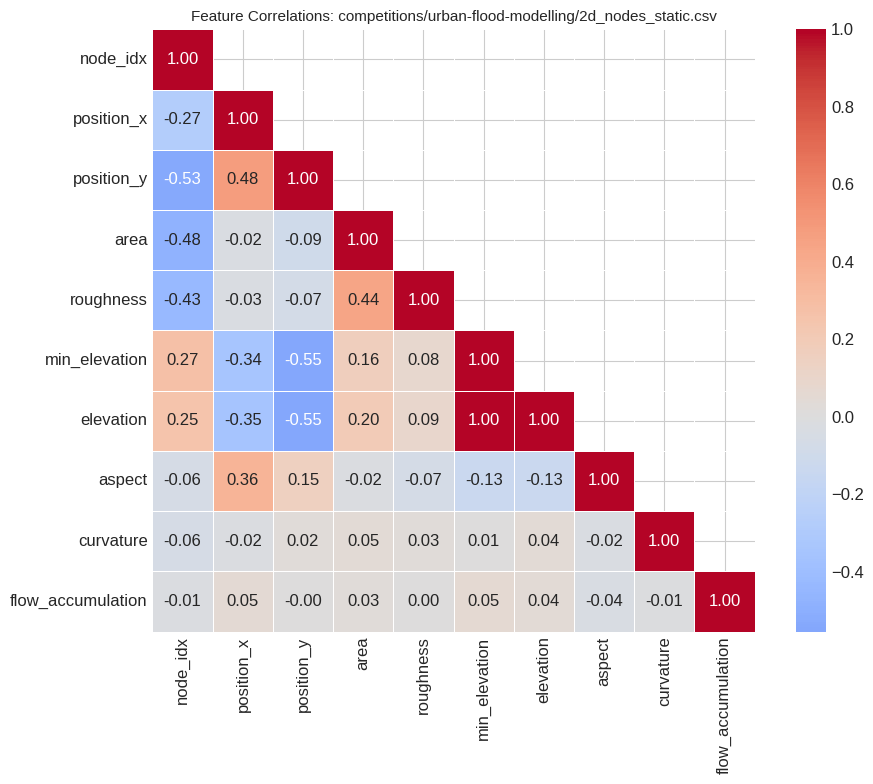

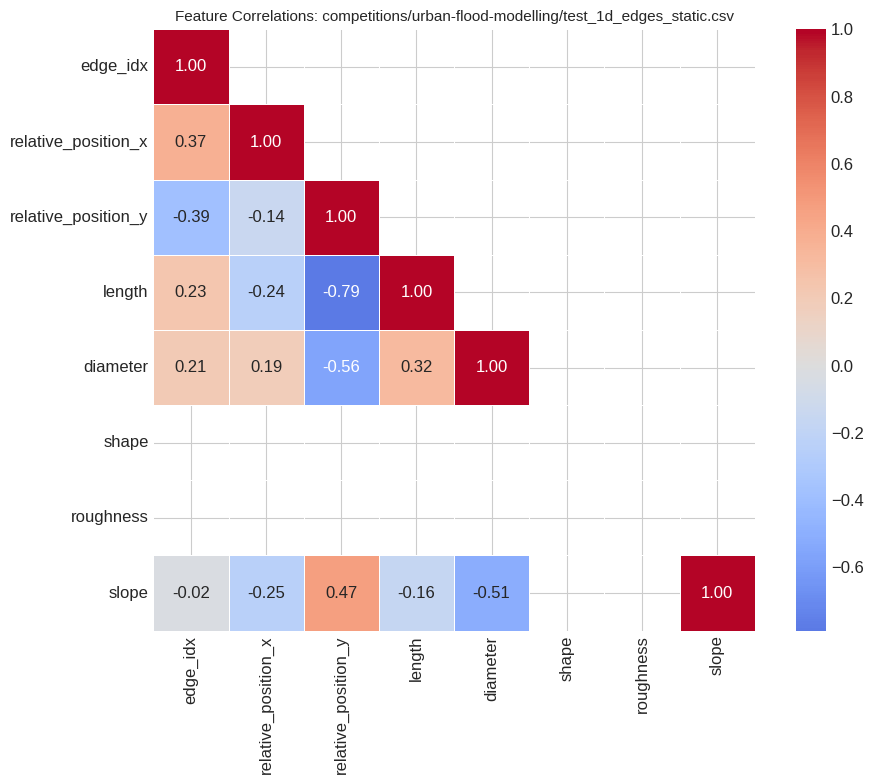

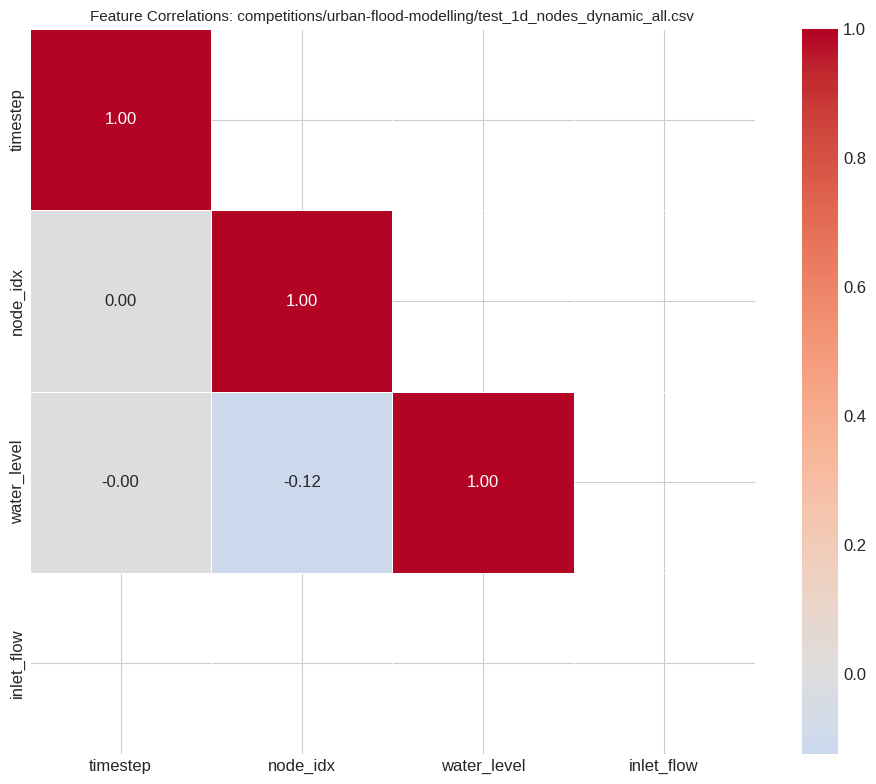

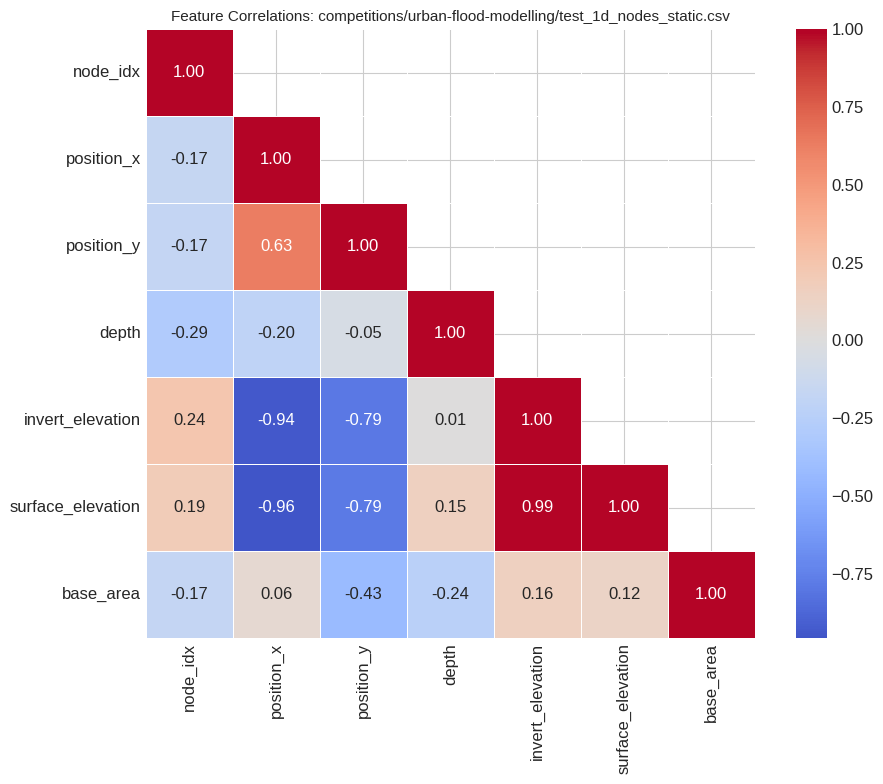

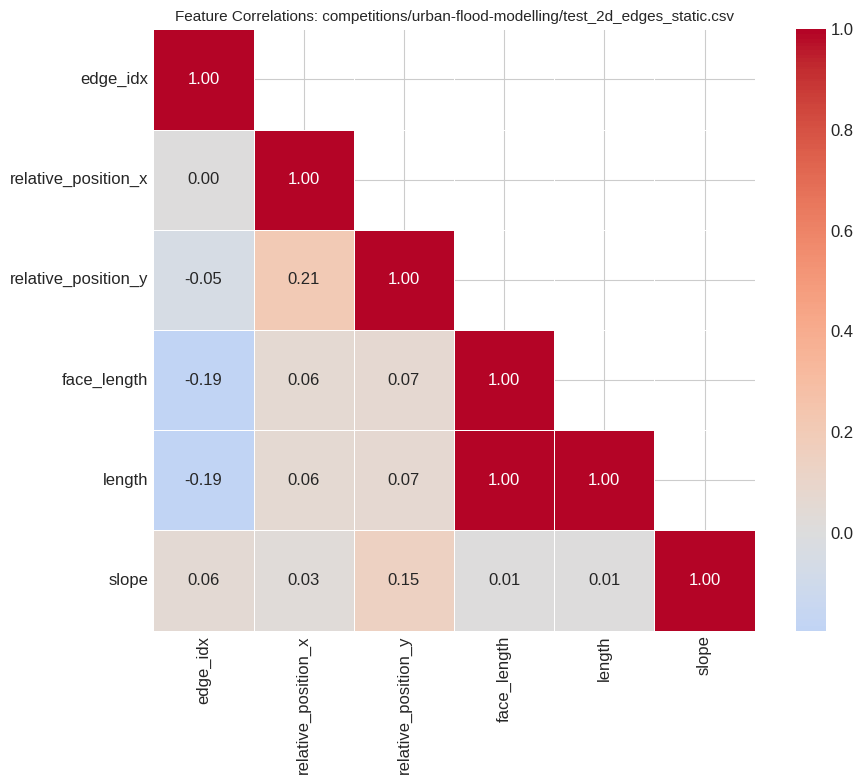

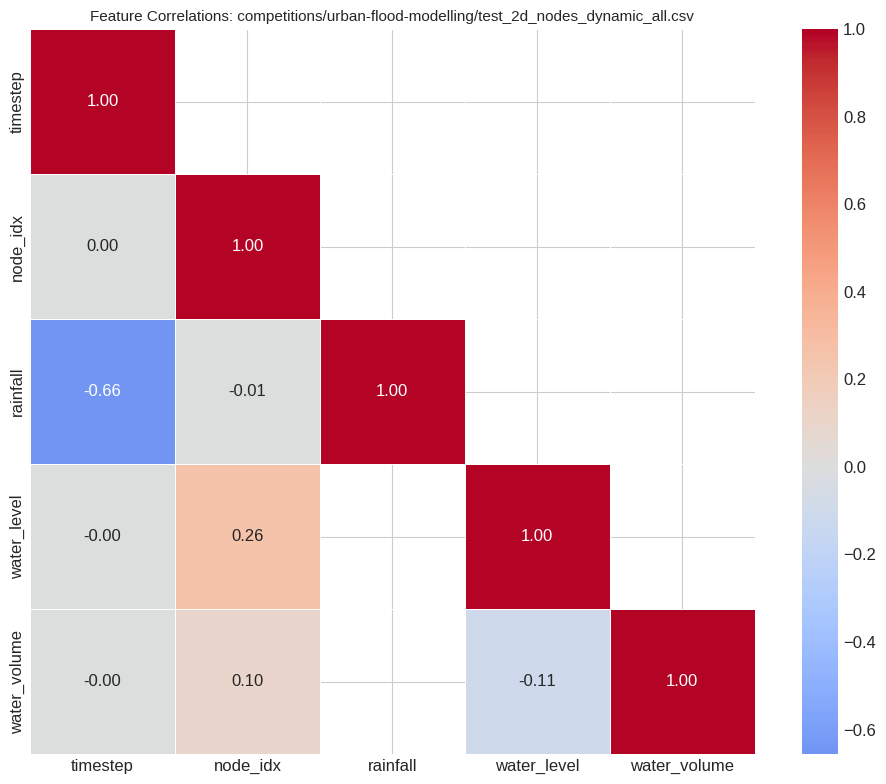

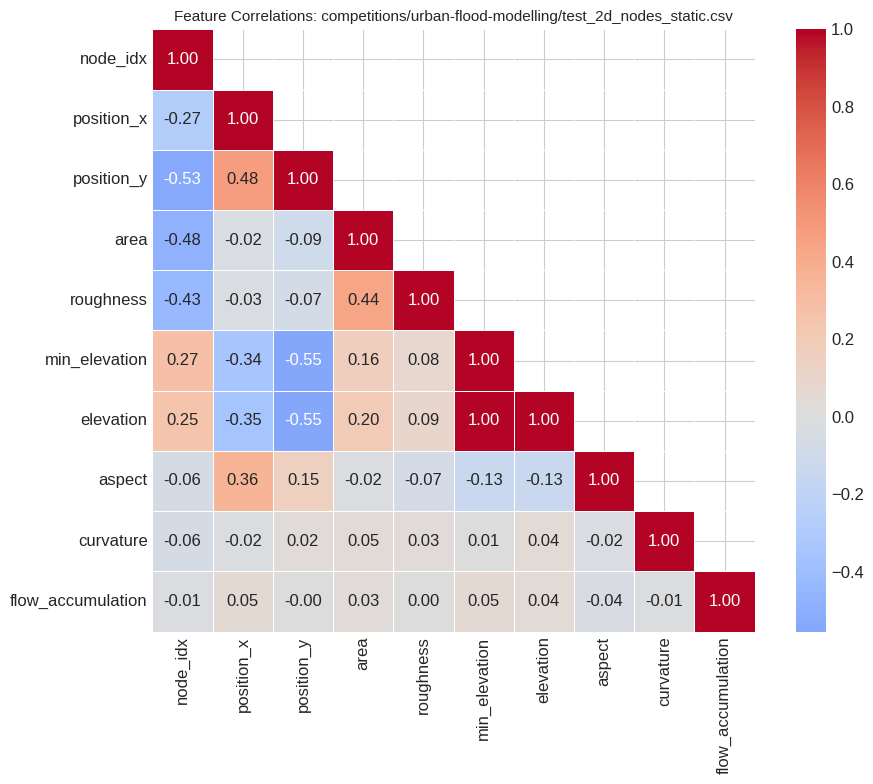

In [12]:
# %% CELL 11 — Correlation Analysis
print("\n" + "=" * 60)
print("📈 FEATURE CORRELATIONS")
print("=" * 60)

for name, df in loaded.items():
    if 'nodes_dynamic' not in name and 'static' not in name:
        continue
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 2:
        corr = df[numeric_cols].corr()
        
        fig, ax = plt.subplots(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                   center=0, ax=ax, square=True, linewidths=0.5)
        ax.set_title(f'Feature Correlations: {name}', fontsize=11)
        plt.tight_layout()
        plt.savefig(f'corr_{name.replace("/", "_").replace(".csv", "")}.png', 
                   dpi=150, bbox_inches='tight')
        plt.show()



🏗️ STATIC FEATURE DISTRIBUTIONS


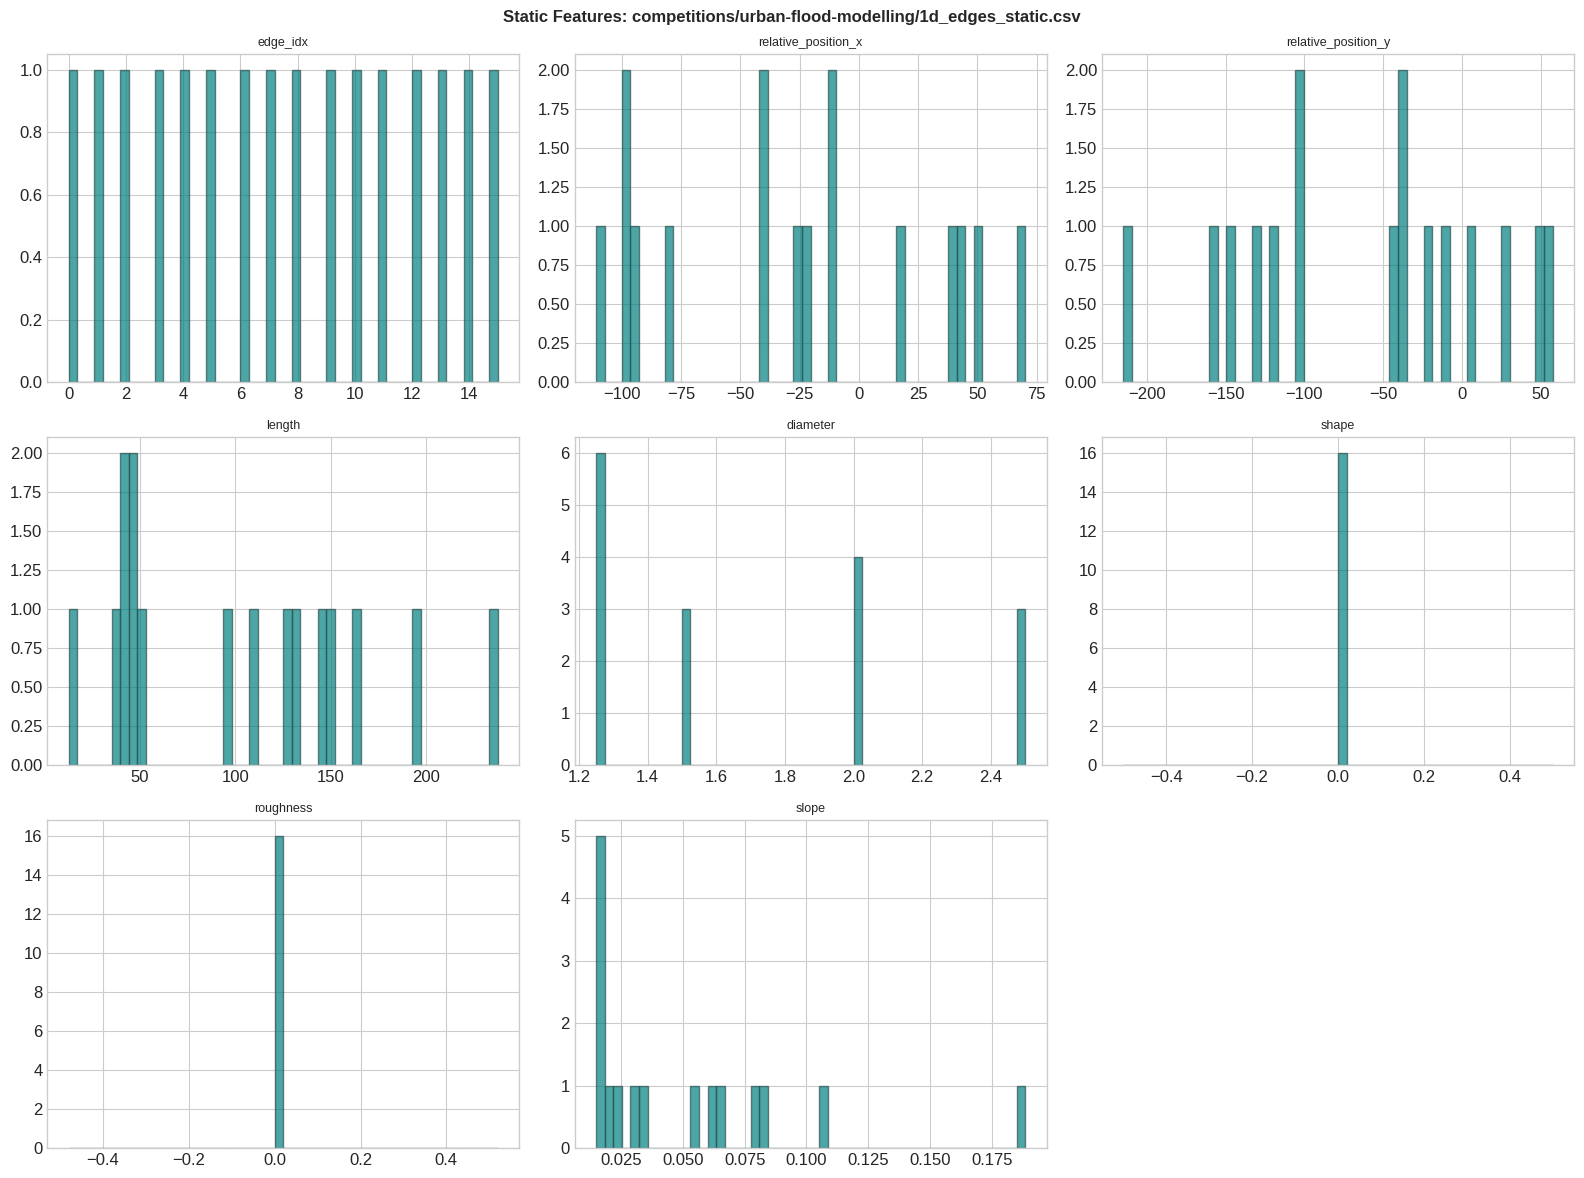

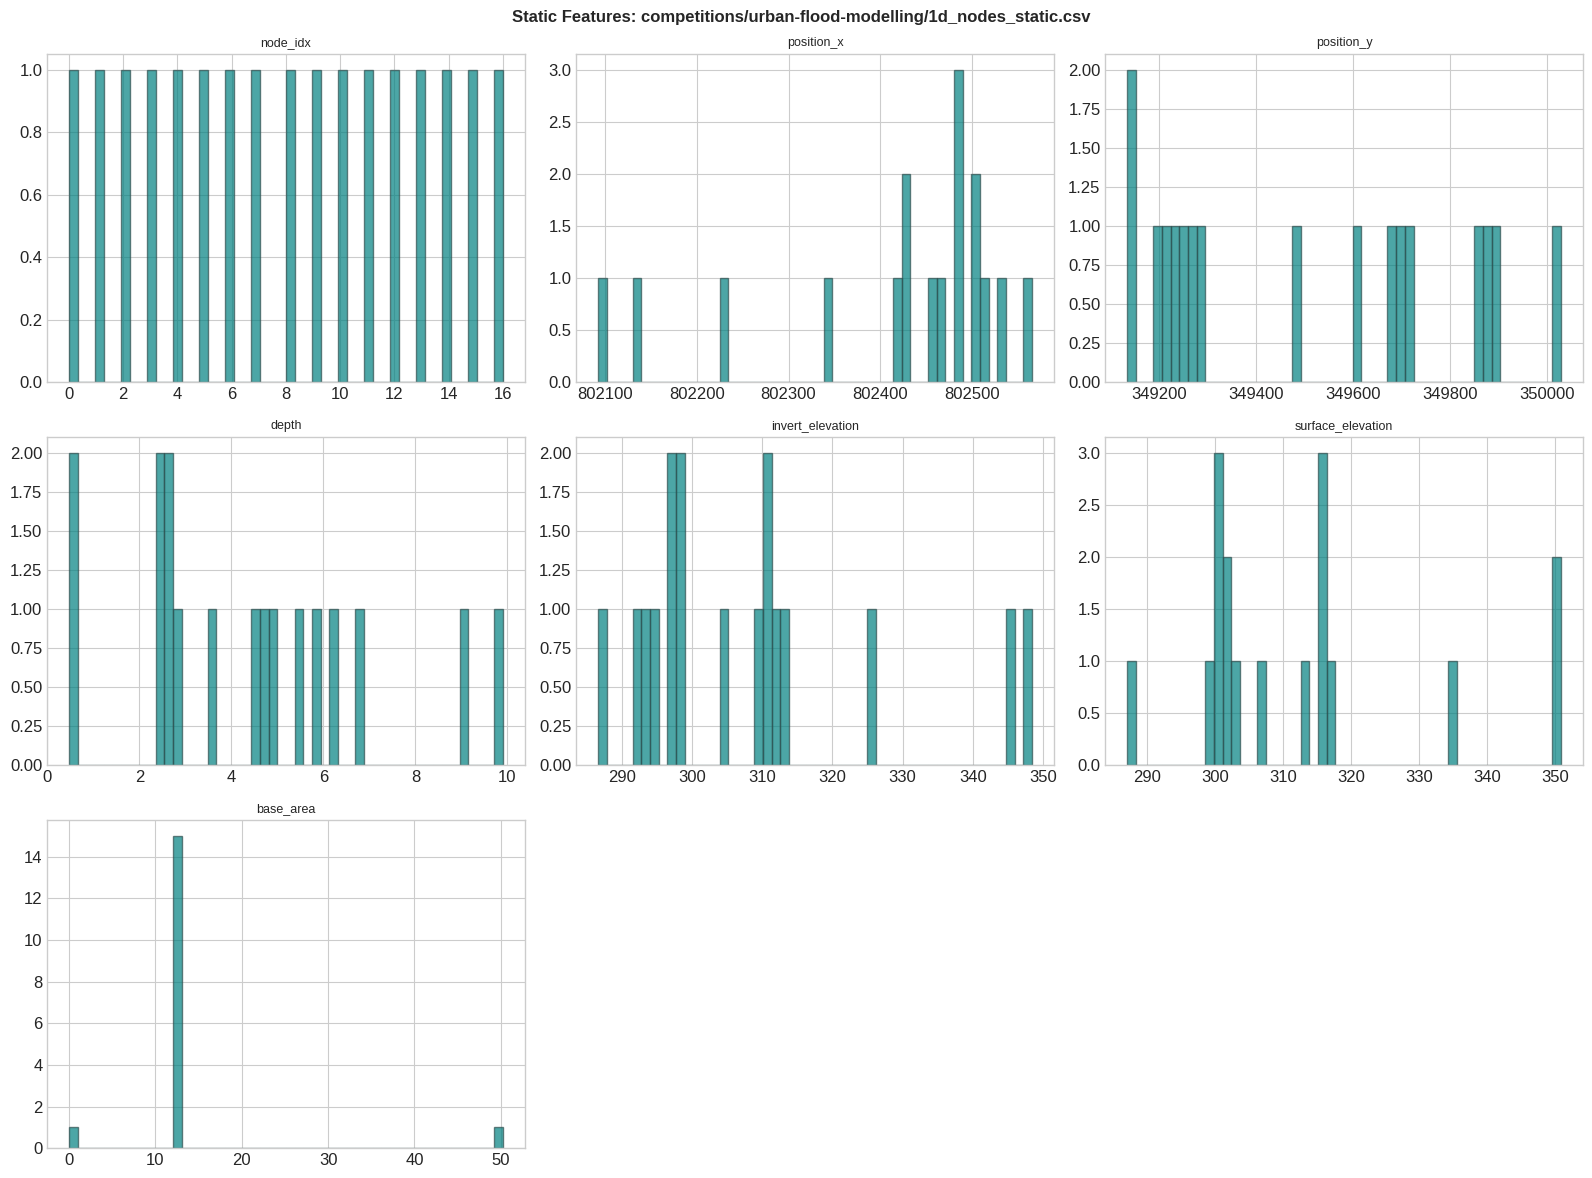

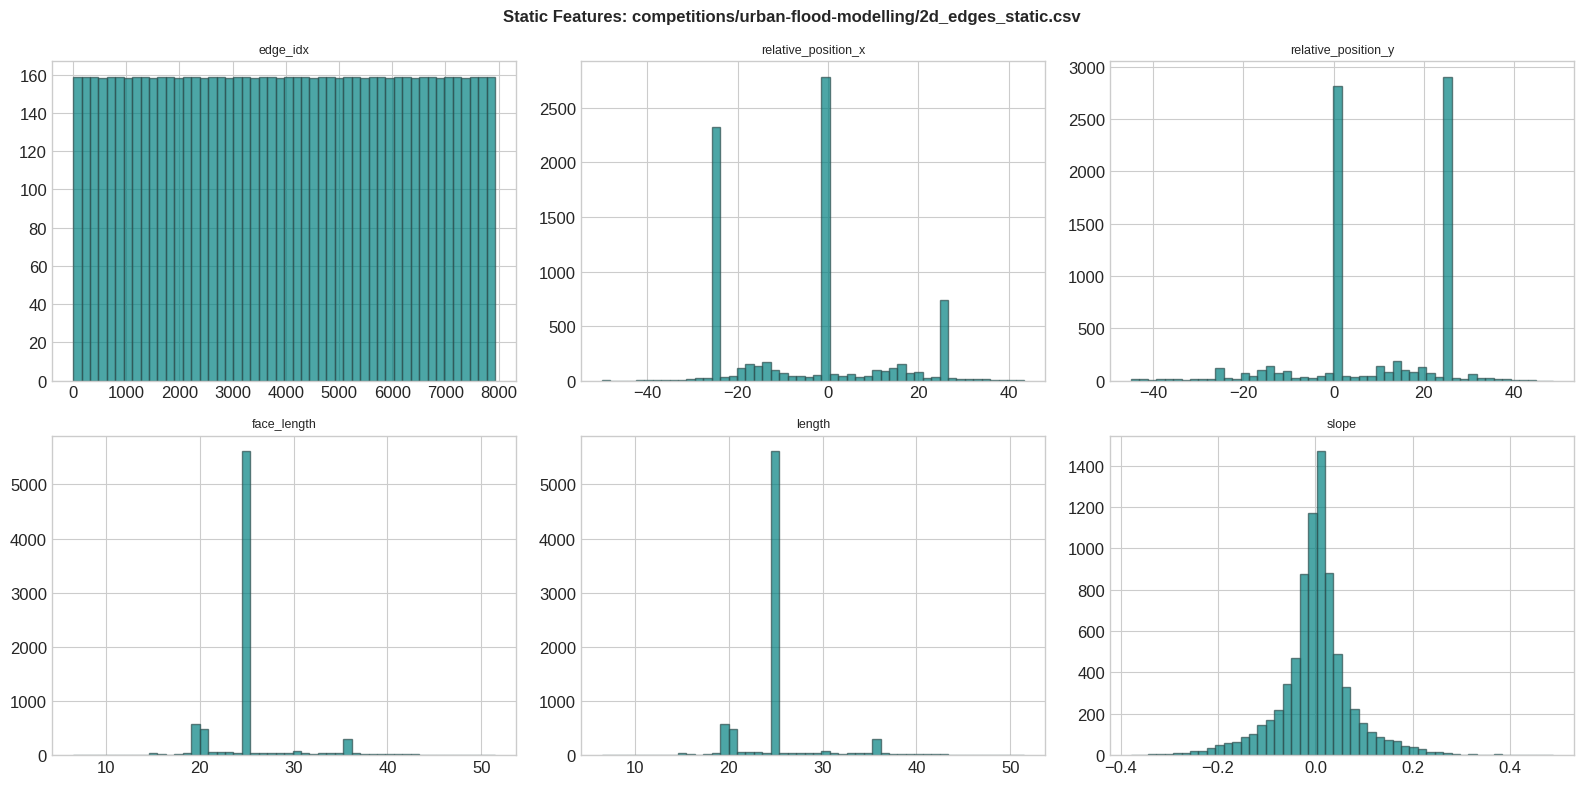

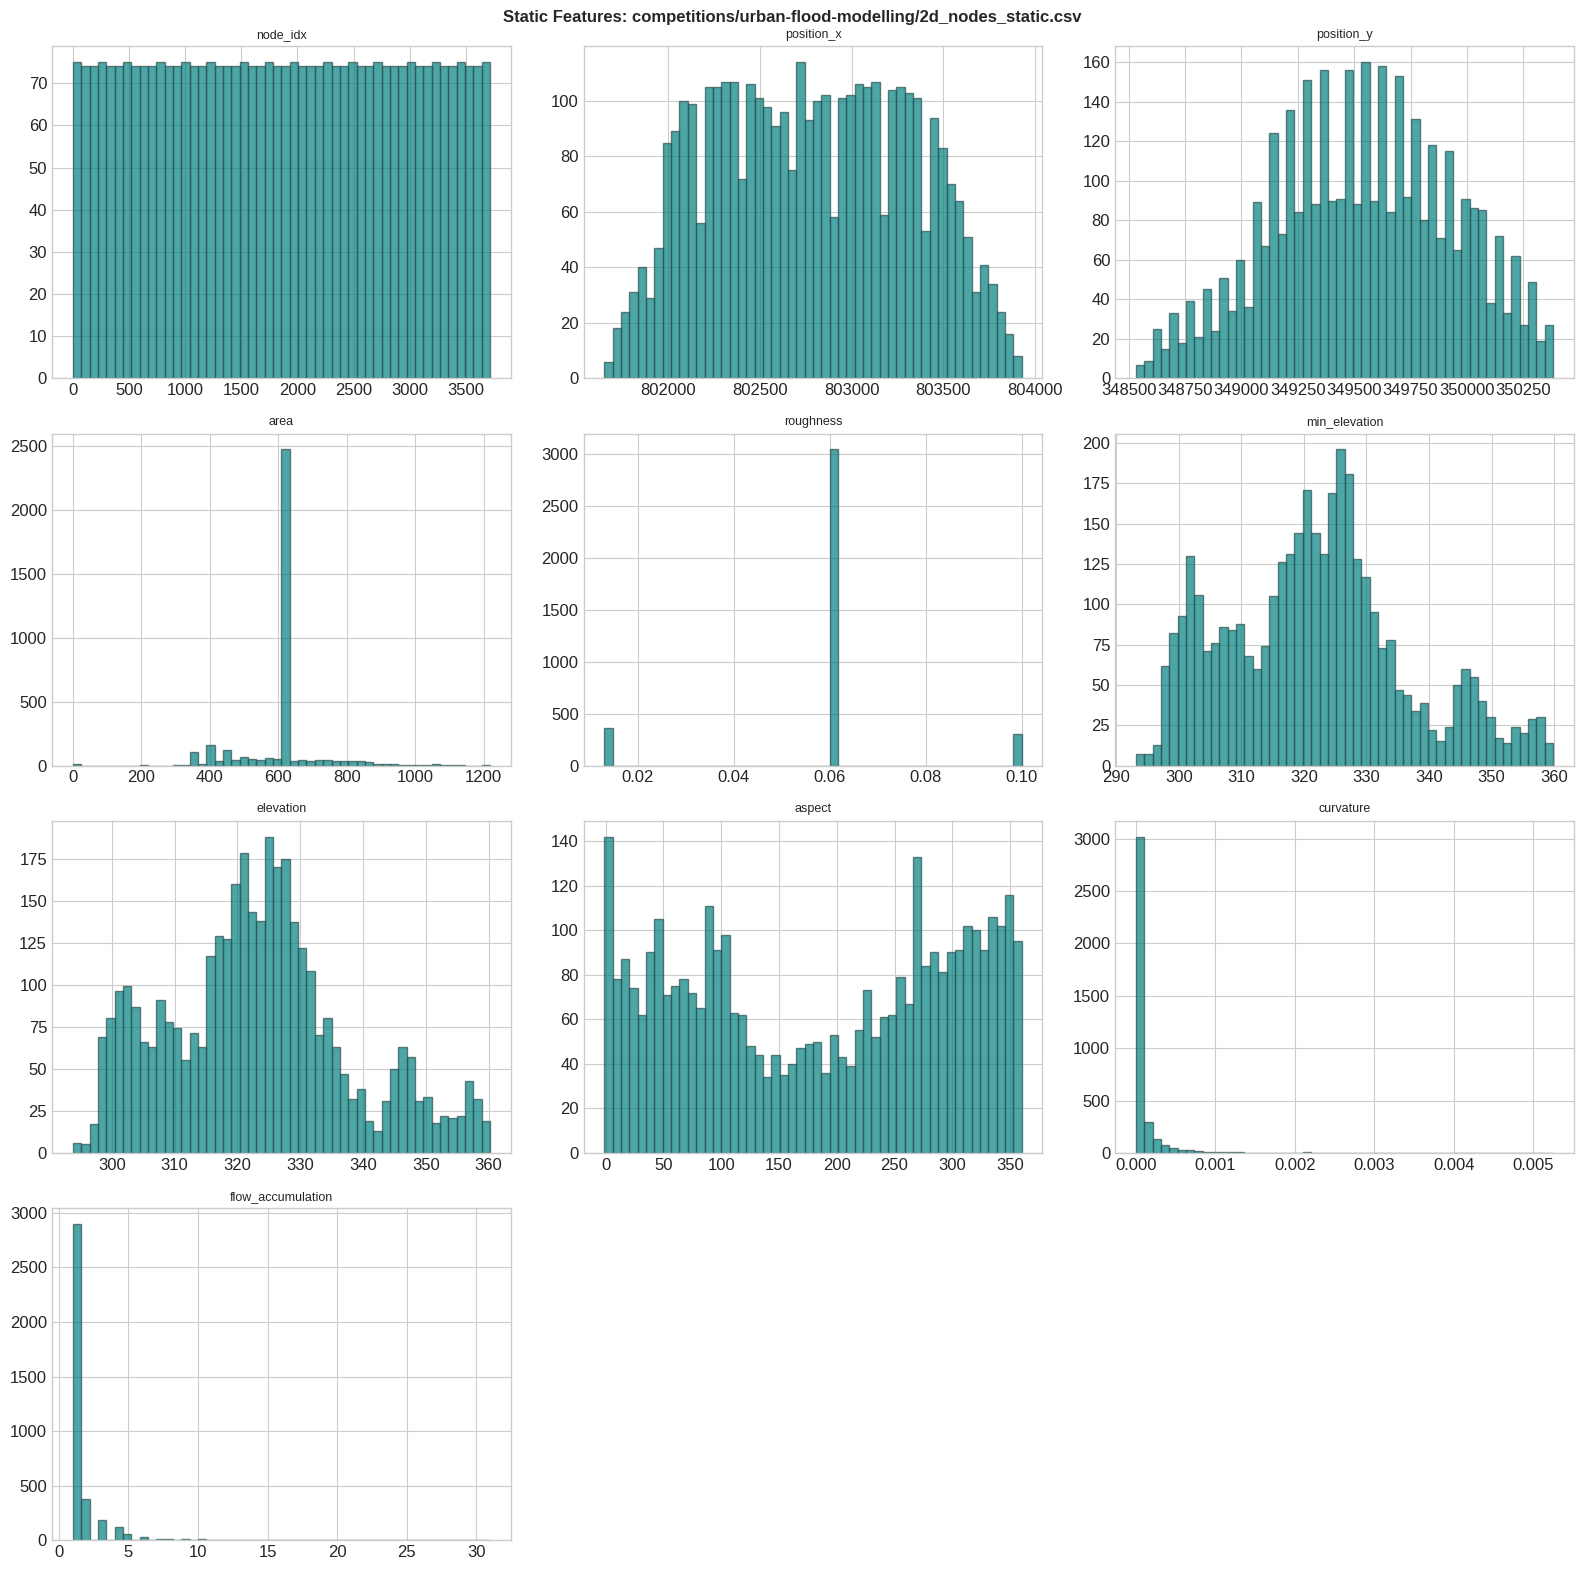

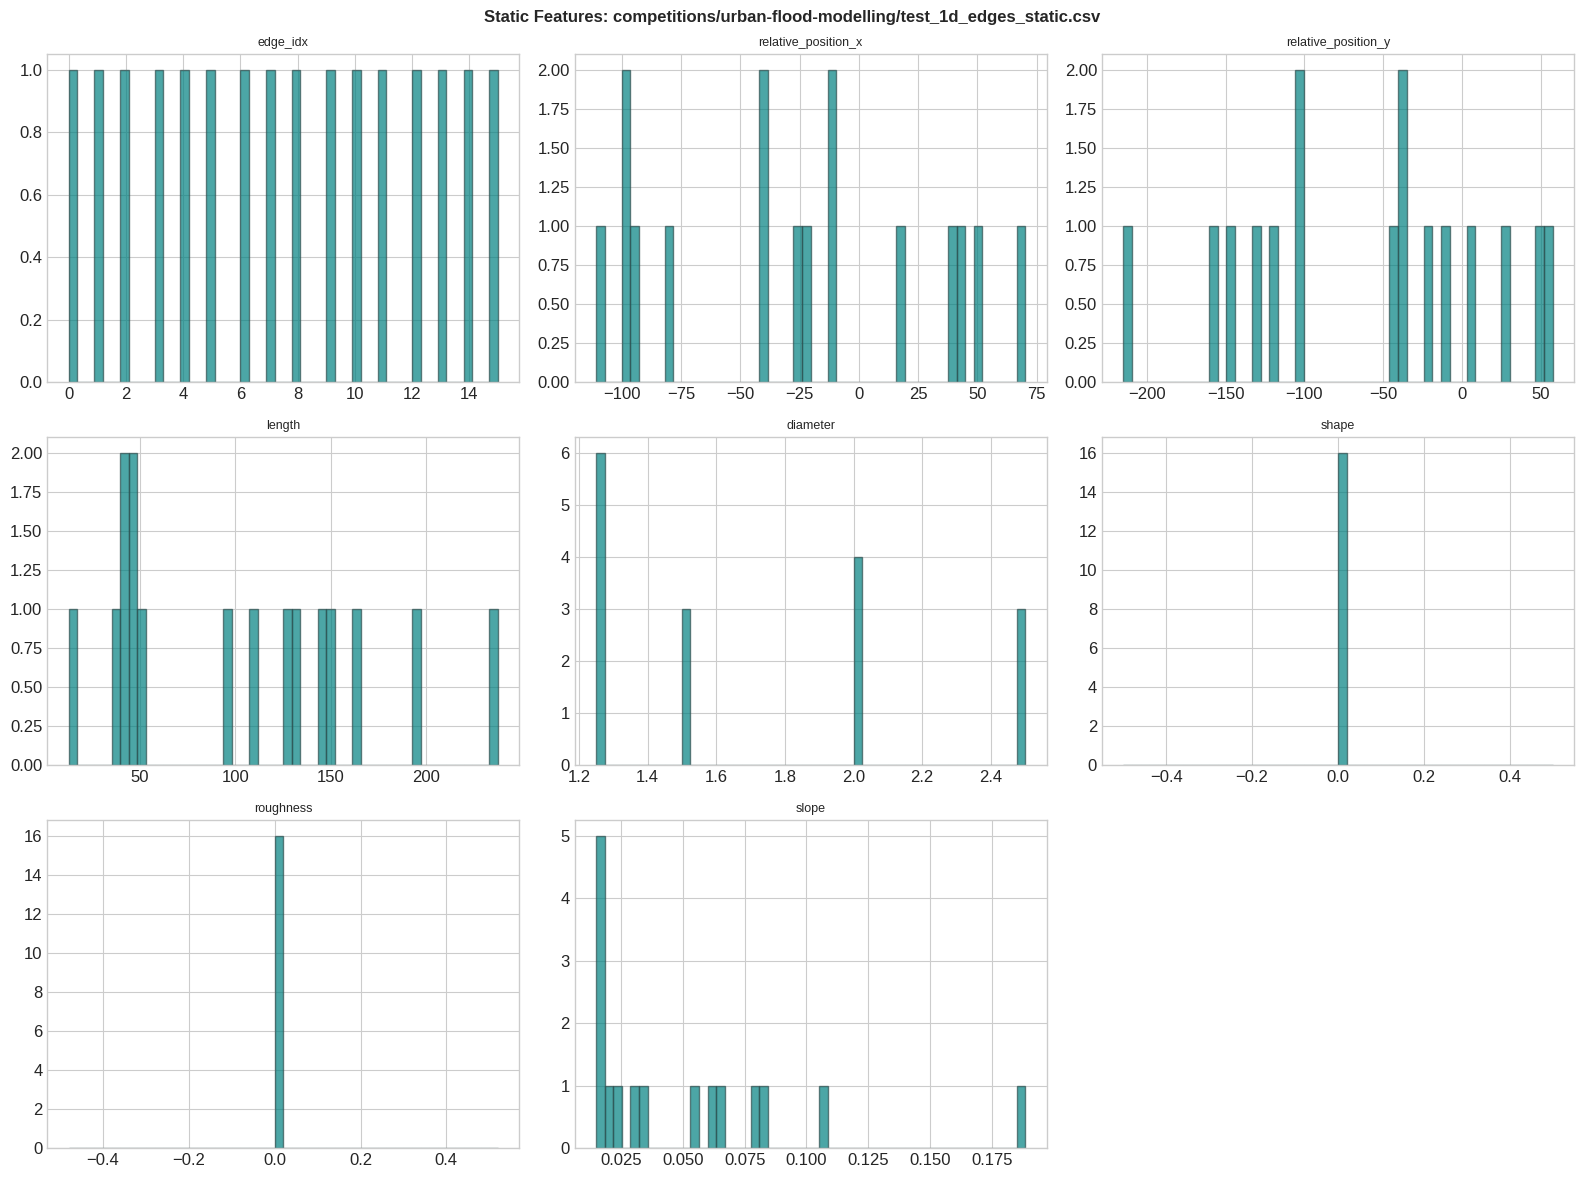

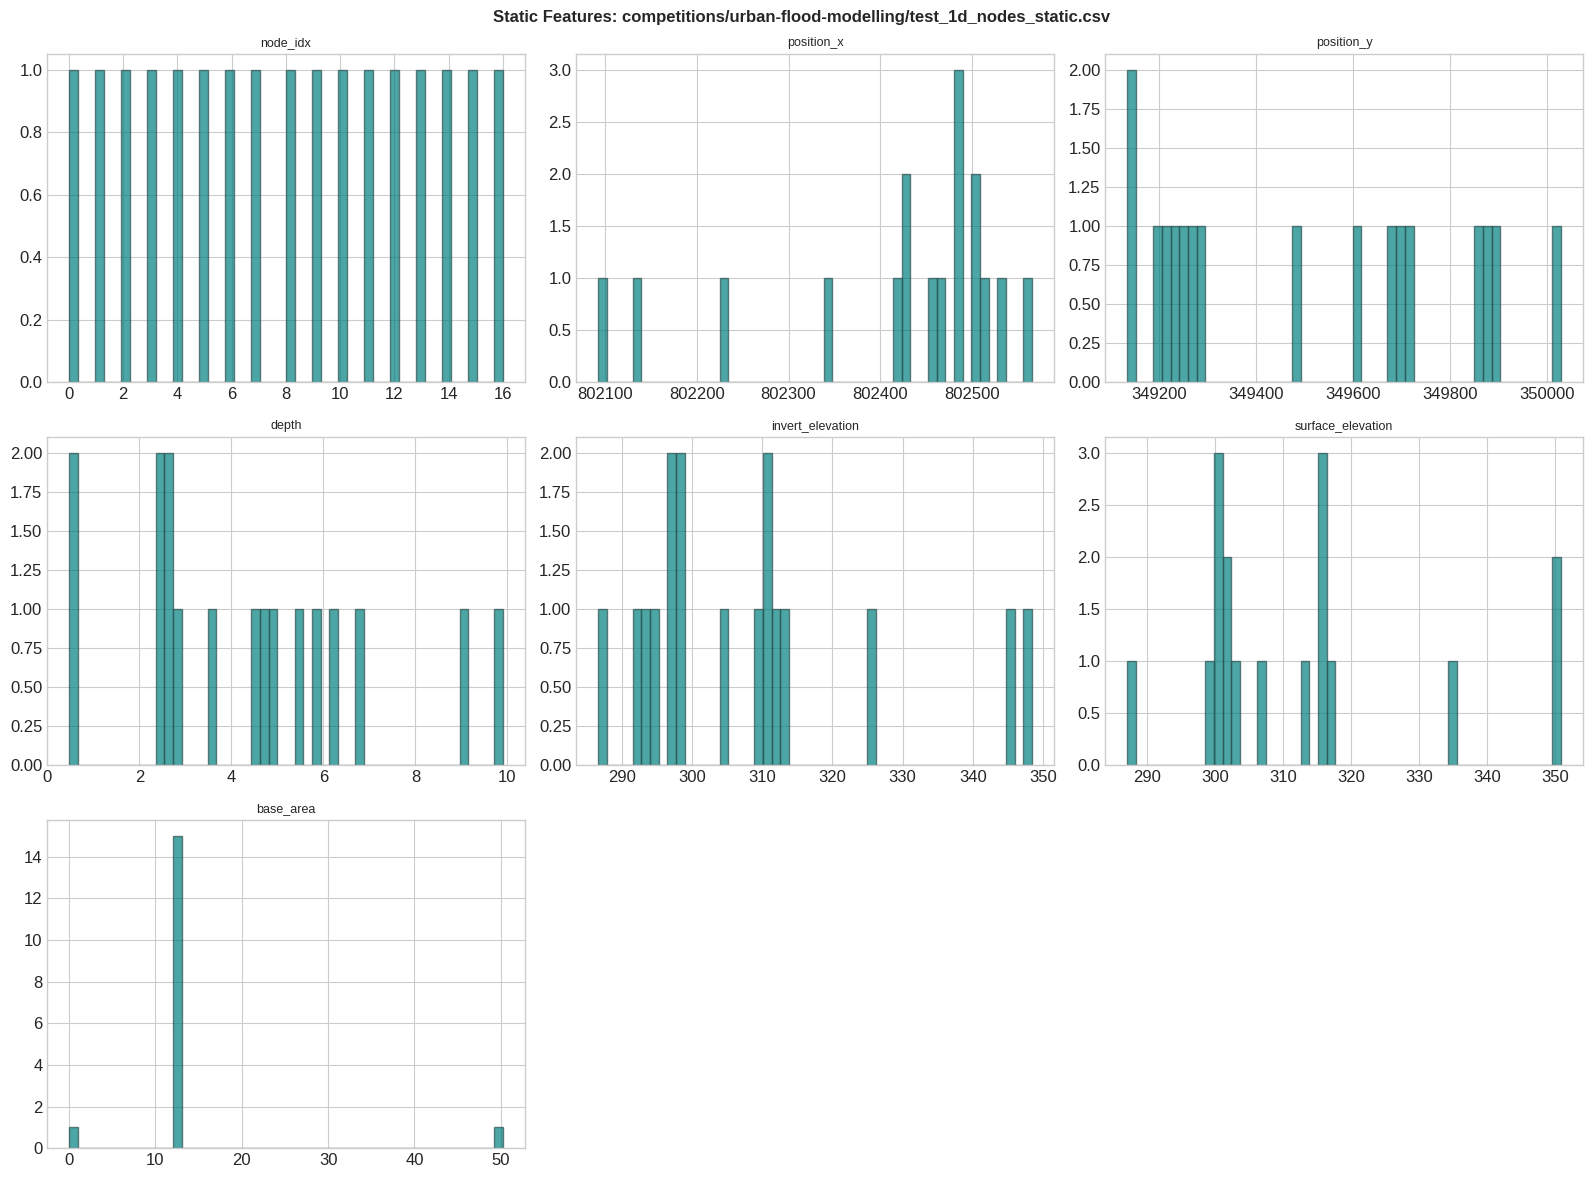

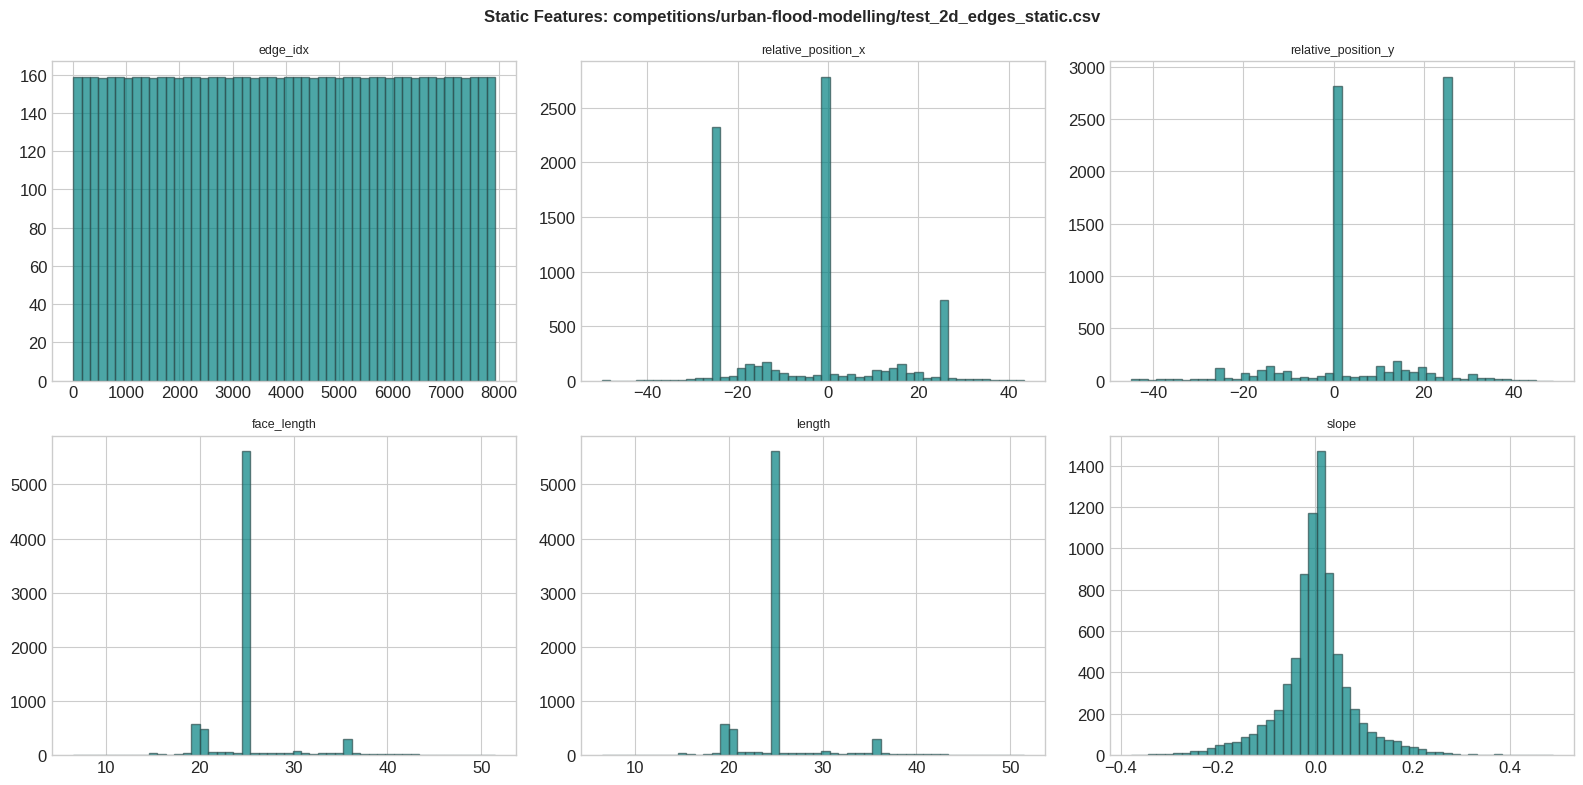

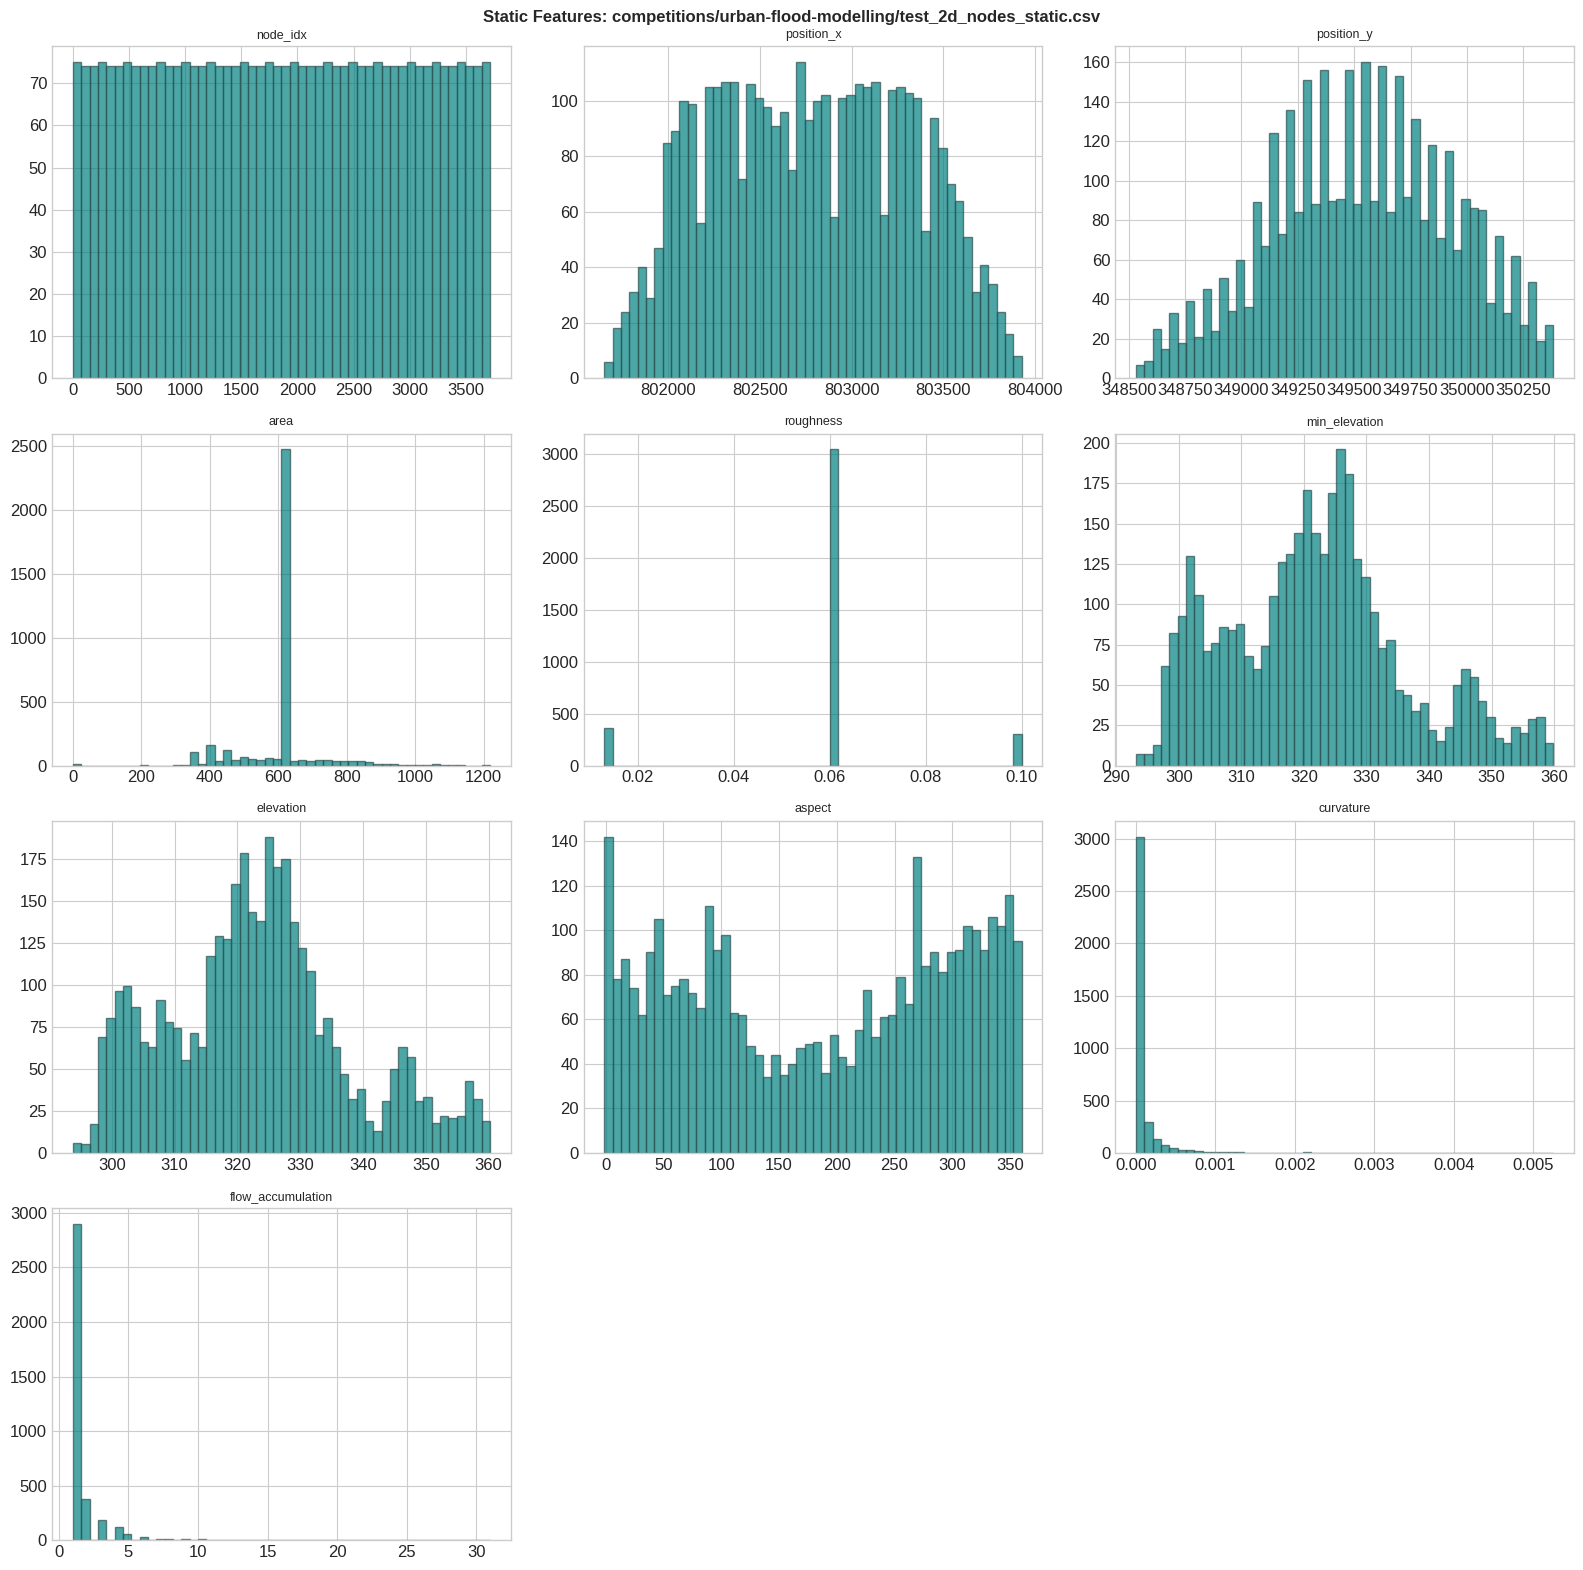

In [13]:
# %% CELL 12 — Static Feature Analysis
print("\n" + "=" * 60)
print("🏗️ STATIC FEATURE DISTRIBUTIONS")
print("=" * 60)

for name, df in loaded.items():
    if 'static' not in name:
        continue
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = len(numeric_cols)
    
    if n_cols > 0:
        n_rows = (n_cols + 2) // 3
        fig, axes = plt.subplots(n_rows, min(3, n_cols), figsize=(16, 4*n_rows))
        if n_rows == 1 and n_cols <= 3:
            axes = np.atleast_2d(axes)
        
        for i, col in enumerate(numeric_cols):
            ax = axes[i // 3, i % 3] if n_cols > 1 else axes[0, 0]
            df[col].hist(bins=50, ax=ax, alpha=0.7, color='teal', edgecolor='darkslategray')
            ax.set_title(col, fontsize=9)
            ax.set_xlabel('')
        
        # Hide unused subplots
        for i in range(n_cols, n_rows * min(3, n_cols)):
            axes[i // 3, i % 3].set_visible(False)
        
        plt.suptitle(f'Static Features: {name}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'static_{name.replace("/", "_").replace(".csv", "")}.png',
                   dpi=150, bbox_inches='tight')
        plt.show()

In [14]:
# %% CELL 13 — Sample Submission Analysis
print("\n" + "=" * 60)
print("📋 SAMPLE SUBMISSION ANALYSIS")
print("=" * 60)

sub_files = {k: v for k, v in loaded.items() if 'submission' in k.lower() or 'sample' in k.lower()}

if not sub_files:
    # Try to find submission files
    for rel, full in all_files:
        if 'submission' in rel.lower() or 'sample' in rel.lower():
            if full.endswith('.csv'):
                sub_files[rel] = pd.read_csv(full)
            elif full.endswith('.parquet'):
                sub_files[rel] = pd.read_parquet(full)

for name, df in sub_files.items():
    print(f"\n--- {name} ---")
    describe_df(df, name=name)
    
    # Analyze submission structure
    if 'model_id' in df.columns:
        print(f"\n  Model IDs: {sorted(df['model_id'].unique())}")
    if 'event_id' in df.columns:
        print(f"  Event IDs per model:")
        for mid in sorted(df['model_id'].unique()):
            events = sorted(df[df['model_id'] == mid]['event_id'].unique())
            print(f"    Model {mid}: events {events}")
    if 'node_type' in df.columns:
        print(f"  Node types: {sorted(df['node_type'].unique())}")
        for mid in sorted(df['model_id'].unique()):
            for nt in sorted(df['node_type'].unique()):
                subset = df[(df['model_id'] == mid) & (df['node_type'] == nt)]
                n_nodes = subset['node_id'].nunique() if 'node_id' in df.columns else 'N/A'
                print(f"    Model {mid}, Type {nt}: {len(subset)} rows, {n_nodes} unique nodes")
    if 'node_id' in df.columns:
        print(f"  Total unique nodes: {df['node_id'].nunique()}")
    print(f"  Total rows to predict: {len(df)}")



📋 SAMPLE SUBMISSION ANALYSIS

--- competitions/urban-flood-modelling/sample_submission.csv ---

  competitions/urban-flood-modelling/sample_submission.csv
  Shape: (50910192, 6)
  Columns: ['row_id', 'model_id', 'event_id', 'node_type', 'node_id', 'water_level']
  Dtypes:
row_id           int64
model_id         int64
event_id         int64
node_type        int64
node_id          int64
water_level    float64

  First 3 rows:
   row_id  model_id  event_id  node_type  node_id  water_level
0       0         1         5          1        0          NaN
1       1         1         5          1        0          NaN
2       2         1         5          1        0          NaN

  Basic Stats:
             row_id      model_id      event_id     node_type       node_id  water_level
count  5.091019e+07  5.091019e+07  5.091019e+07  5.091019e+07  5.091019e+07          0.0
mean   2.545510e+07  1.634401e+00  5.559805e+01  1.970403e+00  1.982073e+03          NaN
std    1.469651e+07  4.815979e-01  2

In [15]:
# %% CELL 14 — Key Numbers Summary
print("\n" + "=" * 60)
print("📊 KEY NUMBERS SUMMARY")
print("=" * 60)

summary = {
    'Total files loaded': len(loaded),
}

# Count nodes per type
for name, df in loaded.items():
    if 'nodes_static' in name or 'nodes_index' in name:
        key = f"Nodes in {name}"
        summary[key] = len(df)
    elif 'edge_index' in name:
        key = f"Edges in {name}"
        summary[key] = len(df)
    elif 'nodes_dynamic' in name:
        ts_col = [c for c in df.columns if 'timestep' in c.lower() or 'time' in c.lower()]
        if ts_col:
            key = f"Timesteps in {name}"
            summary[key] = df[ts_col[0]].nunique()
        key = f"Total rows in {name}"
        summary[key] = len(df)

for k, v in summary.items():
    print(f"  {k}: {v:,}")


📊 KEY NUMBERS SUMMARY
  Total files loaded: 26
  Edges in competitions/urban-flood-modelling/1d_edge_index.csv: 16
  Timesteps in competitions/urban-flood-modelling/1d_nodes_dynamic_all.csv: 94
  Total rows in competitions/urban-flood-modelling/1d_nodes_dynamic_all.csv: 1,598
  Nodes in competitions/urban-flood-modelling/1d_nodes_static.csv: 17
  Edges in competitions/urban-flood-modelling/2d_edge_index.csv: 7,935
  Timesteps in competitions/urban-flood-modelling/2d_nodes_dynamic_all.csv: 94
  Total rows in competitions/urban-flood-modelling/2d_nodes_dynamic_all.csv: 349,304
  Nodes in competitions/urban-flood-modelling/2d_nodes_static.csv: 3,716
  Edges in competitions/urban-flood-modelling/test_1d_edge_index.csv: 16
  Timesteps in competitions/urban-flood-modelling/test_1d_nodes_dynamic_all.csv: 445
  Total rows in competitions/urban-flood-modelling/test_1d_nodes_dynamic_all.csv: 7,565
  Nodes in competitions/urban-flood-modelling/test_1d_nodes_static.csv: 17
  Edges in competitions

In [16]:
# %% CELL 15 — Test Set: What We Need to Predict
print("\n" + "=" * 60)
print("🎯 TEST SET ANALYSIS — What We Need to Predict")
print("=" * 60)

for name, df in loaded.items():
    if 'test' not in name.lower() or 'dynamic' not in name:
        continue
    
    print(f"\n--- {name} ---")
    ts_col = [c for c in df.columns if 'timestep' in c.lower() or 'time' in c.lower()]
    wl_cols = [c for c in df.columns if 'water' in c.lower() and 'level' in c.lower()]
    
    if ts_col:
        ts = ts_col[0]
        print(f"  Timestep range: {df[ts].min()} to {df[ts].max()}")
        print(f"  Number of timesteps: {df[ts].nunique()}")
    
    if wl_cols:
        wl = wl_cols[0]
        non_null = df[wl].notna().sum()
        null = df[wl].isna().sum()
        print(f"  Water level — provided: {non_null}, to predict (NaN): {null}")
        
        # Check which timesteps have water level data (warmup)
        if ts_col:
            warmup_ts = df[df[wl].notna()][ts].unique()
            predict_ts = df[df[wl].isna()][ts].unique()
            print(f"  Warmup timesteps (with WL): {sorted(warmup_ts)[:15]}...")
            print(f"  Prediction timesteps (no WL): {len(predict_ts)} timesteps")

print("\n✅ EDA COMPLETE!")
print("=" * 60)



🎯 TEST SET ANALYSIS — What We Need to Predict

--- competitions/urban-flood-modelling/test_1d_edges_dynamic_all.csv ---
  Timestep range: 0 to 444
  Number of timesteps: 445

--- competitions/urban-flood-modelling/test_1d_nodes_dynamic_all.csv ---
  Timestep range: 0 to 444
  Number of timesteps: 445
  Water level — provided: 170, to predict (NaN): 7395
  Warmup timesteps (with WL): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]...
  Prediction timesteps (no WL): 435 timesteps

--- competitions/urban-flood-modelling/test_2d_edges_dynamic_all.csv ---
  Timestep range: 0 to 444
  Number of timesteps: 445

--- competitions/urban-flood-modelling/test_2d_nodes_dynamic_all.csv ---
  Timestep range: 0 to 444
  Number of timesteps: 445
  Water level — provided: 37160, to predict (NaN): 1616460
  Warmup timesteps (with WL): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(